# Напишите заголовок проекта здесь

- Автор: Туровская Мария Сергеевна
- Дата:30.06.2026

### Цели и задачи проекта

<font color='#777778'>
Провести исследовательский анализ рынка общественного питания в Москве, чтобы выбрать расположение нового кафе, цены и меню.</font>

### Описание данных

<font color='#777778'>

- name — название заведения;

- address — адрес заведения;
- district — административный район, в котором находится заведение, например Центральный административный округ;

- category — категория заведения, например «кафе», «пиццерия» или «кофейня»;
hours — информация о днях и часах работы;
rating — рейтинг заведения по оценкам пользователей в Яндекс Картах (высшая оценка — 5.0);

- chain — число, выраженное 0 или 1, которое показывает, является ли заведение сетевым (для маленьких сетей могут встречаться ошибки):
0 — заведение не является сетевым;
1 — заведение является сетевым.

- seats — количество посадочных мест.

Файл /datasets/rest_price.csv содержит информацию о среднем чеке в заведениях общественного питания:

- price — категория цен в заведении, например «средние», «ниже среднего», «выше среднего» и так далее;

- avg_bill — строка, которая хранит среднюю стоимость заказа в виде диапазона, например:
- «Средний счёт: 1000–1500 ₽»;

- «Цена чашки капучино: 130–220 ₽»;

- «Цена бокала пива: 400–600 ₽».
и так далее;

- middle_avg_bill — число с оценкой среднего чека, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Средний счёт»:

- Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
- Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
- Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.
- middle_coffee_cup — число с оценкой одной чашки капучино, которое указано только для значений из столбца avg_bill, начинающихся с подстроки «Цена одной чашки капучино»:
- Если в строке указан ценовой диапазон из двух значений, в столбец войдёт медиана этих двух значений.
- Если в строке указано одно число — цена без диапазона, то в столбец войдёт это число.
Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино», то в столбец ничего не войдёт.

</font>

### Содержимое проекта

<font color='#777778'>

- Шаг 1. Изучение данных о заведениях общественного питания в Москве, изучение типов данных, особенностей и создание предварительного вывода

- Шаг 2. Предобработка данных к исследовательскому анализу, очистка данных

- Шаг 3. Исследовтельский анализ данных и ответы на вопросы исследования

- Шаг 4. Итоговый вывод и рекомендации на основе анализа данных
</font>

---

## 1. Загрузка данных и знакомство с ними

- Загрузите данные о заведениях общественного питания Москвы. Путь к файлам: `/datasets/rest_info.csv` и `/datasets/rest_price.csv`.

- Познакомьтесь с данными и изучите общую информацию о них.

In [ ]:
#Получим данные о файлах
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
rest_info = pd.read_csv('https://code.s3.yandex.net/datasets/rest_info.csv')
rest_price = pd.read_csv('https://code.s3.yandex.net/datasets/rest_price.csv')


In [ ]:
rest_info.head()

,id,name,category,address,district,hours,rating,chain,seats
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0


In [ ]:
rest_info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        8406 non-null   object 
 1   name      8406 non-null   object 
 2   category  8406 non-null   object 
 3   address   8406 non-null   object 
 4   district  8406 non-null   object 
 5   hours     7870 non-null   object 
 6   rating    8406 non-null   float64
 7   chain     8406 non-null   int64  
 8   seats     4795 non-null   float64
dtypes: float64(2), int64(1), object(6)
memory usage: 591.2+ KB


In [ ]:
rest_price.head()

,id,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,045780ada3474c57a2112e505d74b633,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
1,1070b6b59144425896c65889347fcff6,средние,Средний счёт:от 1000 ₽,1000.0,NaN
2,03ac7cd772104f65b58b349dc59f03ee,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
3,a163aada139c4c7f87b0b1c0b466a50f,средние,Средний счёт:400–600 ₽,500.0,NaN
4,8a343546b24e4a499ad96eb7d0797a8a,средние,NaN,NaN,NaN


In [ ]:
rest_price.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4058 entries, 0 to 4057
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 4058 non-null   object 
 1   price              3315 non-null   object 
 2   avg_bill           3816 non-null   object 
 3   middle_avg_bill    3149 non-null   float64
 4   middle_coffee_cup  535 non-null    float64
dtypes: float64(2), object(3)
memory usage: 158.6+ KB


---

### Промежуточный вывод

Сделайте промежуточный вывод о полученных данных: данные какого объёма вам предоставили, соответствуют ли данные описанию, встречаются ли в них пропуски, используются ли верные типы данных. Отметьте другие особенности данных, которые вы обнаружите на этой стадии и на которые стоит обратить внимание при предобработке.



*   Данные соответствуют описанию в обоих датасетах, они представлены в типе object, что нужно будет изменить на соответствующий тип данных: int64 и string дл правильного анализа. Все числовые значения нужно поменять из object в float/int
*   В датасете rest_info есть пропуски в hours, seats
*   В дата rest_prices есть пропуски во всех стобцах кроме id
*   Все данные представлены в типе snake case, что менять не будем





### Подготовка единого датафрейма

- Объедините данные двух датасетов в один, с которым вы и продолжите работу.

In [ ]:
#Объединим два датасета по ключу id
data=rest_info.merge(rest_price, on='id', how='left')

In [ ]:
data.describe()

,rating,chain,seats,middle_avg_bill,middle_coffee_cup
count,8406.000000,8406.000000,4795.000000,3149.000000,535.000000
mean,4.229895,0.381275,108.421689,958.053668,174.721495
std,0.470348,0.485729,122.833396,1009.732845,88.951103
min,1.000000,0.000000,0.000000,0.000000,60.000000
25%,4.100000,0.000000,40.000000,375.000000,124.500000
50%,4.300000,0.000000,75.000000,750.000000,169.000000
75%,4.400000,1.000000,140.000000,1250.000000,225.000000
max,5.000000,1.000000,1288.000000,35000.000000,1568.000000


In [ ]:
data.head()

,id,name,category,address,district,hours,rating,chain,seats,price,avg_bill,middle_avg_bill,middle_coffee_cup
0,0c3e3439a8c64ea5bf6ecd6ca6ae19f0,WoWфли,кафе,"Москва, улица Дыбенко, 7/1",Северный административный округ,"ежедневно, 10:00–22:00",5.0,0,NaN,NaN,NaN,NaN,NaN
1,045780ada3474c57a2112e505d74b633,Четыре комнаты,ресторан,"Москва, улица Дыбенко, 36, корп. 1",Северный административный округ,"ежедневно, 10:00–22:00",4.5,0,4.0,выше среднего,Средний счёт:1500–1600 ₽,1550.0,NaN
2,1070b6b59144425896c65889347fcff6,Хазри,кафе,"Москва, Клязьминская улица, 15",Северный административный округ,"пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00...",4.6,0,45.0,средние,Средний счёт:от 1000 ₽,1000.0,NaN
3,03ac7cd772104f65b58b349dc59f03ee,Dormouse Coffee Shop,кофейня,"Москва, улица Маршала Федоренко, 12",Северный административный округ,"ежедневно, 09:00–22:00",5.0,0,NaN,NaN,Цена чашки капучино:155–185 ₽,NaN,170.0
4,a163aada139c4c7f87b0b1c0b466a50f,Иль Марко,пиццерия,"Москва, Правобережная улица, 1Б",Северный административный округ,"ежедневно, 10:00–22:00",5.0,1,148.0,средние,Средний счёт:400–600 ₽,500.0,NaN


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   float64
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: float64(4), int64(1), object(8)
memory usage: 853.9+ KB


1.  В датасете 8406 строк и 13 столбцов, что делает его массивом данных

2. Колонки rating, chain(принимает значение 1 и 0), seats(имеет тип float, чо неправильно тк количество мест не может быть не целочисленным), middle_avg_bill, middle_coffee_cup имеют числовые типы данных. Все остальные колонки имеют категориальный тип object,что нужно изменить для корректного анализа данных

3. Пропуски есть в данных о часах работы заведений hours (546 cтрок), количестве посадочных мест seats (3611 пропусков), информации о цене price (5091 пропусков), среднем чеке avg_bill (4590 пропусков), о числе с оценкой среднего чека middle_avg_bill(5257 пропусков), о числе с оценкой одной чашки капучино middle_coffee_cup (7871 пропусков)

4. Необходимо преобразовать все данные типа object в str для текстовых данных и в int/float для числовых данных для корректного анализа

5. Данные содержат много пропусков, необходимо обработать данные, очистить от лишних символов и преобразовать в корректный тип


## 2. Предобработка данных

Подготовьте данные к исследовательскому анализу:

- Изучите корректность типов данных и при необходимости проведите их преобразование.

In [ ]:
#Выводим типы данных в каждом столбце
data.dtypes

,0
id,object
name,object
category,object
address,object
district,object
hours,object
rating,float64
chain,int64
seats,float64
price,object


In [ ]:
#Было замечено что значение количества посадочных мест имеет тип float, что нелогично тк оно должно быть
#целочисленным
data['seats'].head()

,seats
0,NaN
1,4.0
2,45.0
3,NaN
4,148.0


In [ ]:
data['seats'] = data['seats'].astype('Int64')

# Проверим тип данных и первые строки столбца 'seats'
print("Информация о столбце 'seats' после преобразования:")
print(f"Dtype: {data['seats'].dtype}")
print(f"Non-Null Count: {data['seats'].count()} (Total: {len(data)})")
print(f"Null Count: {data['seats'].isnull().sum()}")
print("\nПервые 5 строк столбца 'seats' после преобразования:")
display(data['seats'].head())

Информация о столбце 'seats' после преобразования:
Dtype: Int64
Non-Null Count: 4795 (Total: 8406)
Null Count: 3611

Первые 5 строк столбца 'seats' после преобразования:


,seats
0,<NA>
1,4
2,45
3,<NA>
4,148


Тип данных нечисловой из за наличия пропусков которые обозначены нечисловым значением. Необходимо найти эти текстовые пропуски, заменить их на настоящие числовые пропуски (NaN) и поменять тип данных столбца.

In [ ]:
#Проверим данные после преобразования
data.dtypes

,0
id,object
name,object
category,object
address,object
district,object
hours,object
rating,float64
chain,int64
seats,Int64
price,object


In [ ]:
#Перед обработкой данных сделаем контроль размера датасета до и после обработки
tmp=data.copy()
len(tmp)

8406

- Изучите пропущенные значения в данных: посчитайте их количество в каждом столбце датафрейме, изучите данные с пропущенными значениями и предположите гипотезы их появления. Проведите обработку пропущенных значений: вы можете заменить пропуски на определённое значение, удалить строки с пропусками или оставить их как есть.

In [ ]:
#Посчитаем количество пропусков в каждом столбце в абсолютных числах и в процентах
missing_values = data.isna().sum()
print("Количество пропусков в каждом столбце:")
print(missing_values)
missing_values_percent = round(data.isna().mean() *100,2)
print("\nПроцент пропусков в каждом столбце:")
print(missing_values_percent)

Количество пропусков в каждом столбце:
id                      0
name                    0
category                0
address                 0
district                0
hours                 536
rating                  0
chain                   0
seats                3611
price                5091
avg_bill             4590
middle_avg_bill      5257
middle_coffee_cup    7871
dtype: int64

Процент пропусков в каждом столбце:
id                    0.00
name                  0.00
category              0.00
address               0.00
district              0.00
hours                 6.38
rating                0.00
chain                 0.00
seats                42.96
price                60.56
avg_bill             54.60
middle_avg_bill      62.54
middle_coffee_cup    93.64
dtype: float64


Статистика 'seats' для заведений с пропущенными 'hours':


,seats
count,300.000000
mean,117.050000
std,168.130625
min,0.000000
25%,40.000000
50%,75.500000
75%,121.000000
max,1288.000000



Статистика 'seats' для заведений без пропущенных 'hours':


,seats
count,4495.000000
mean,107.845829
std,119.202354
min,0.000000
25%,40.000000
50%,75.000000
75%,140.000000
max,1288.000000


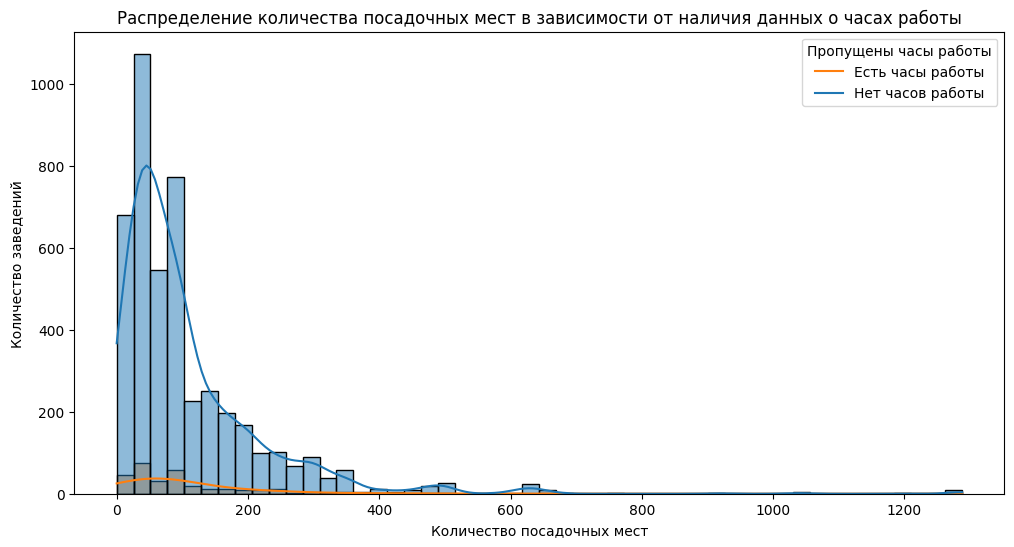

In [ ]:
# Начнем изучение появления пропусков в часах работы заведений и зависимости от количества посадочных мест чтобы проверить гипотезу что пропуски появляются тк заведение небольшое или
#не предполагает посадочные места или не постит инфу
# Создадим временную копию датафрейма для анализа, чтобы не изменять исходный 'data'
analysis_df = data.copy()

# Создадим временный столбец для обозначения пропусков в 'hours' в копии
analysis_df['hours_missing'] = analysis_df['hours'].isna()

# Convert 'seats' column to float type to avoid 'object arrays not supported' error in histplot
# This implicitly converts pandas.NA to numpy.nan, which seaborn can handle.
analysis_df['seats'] = analysis_df['seats'].astype(float)

# Сравним статистику столбца 'seats' для заведений с пропущенными 'hours' и без
print("Статистика 'seats' для заведений с пропущенными 'hours':")
display(analysis_df[analysis_df['hours_missing']]['seats'].describe())

print("\nСтатистика 'seats' для заведений без пропущенных 'hours':")
display(analysis_df[~analysis_df['hours_missing']]['seats'].describe())

# Визуализируем распределение 'seats' для обеих групп
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.histplot(data=analysis_df, x='seats', hue='hours_missing', kde=True, bins=50)
plt.title('Распределение количества посадочных мест в зависимости от наличия данных о часах работы')
plt.xlabel('Количество посадочных мест')
plt.ylabel('Количество заведений')
plt.legend(title='Пропущены часы работы', labels=['Есть часы работы', 'Нет часов работы'])
plt.show()

Гипотеза не отвергается. Действительно, в среднем, заведения, у которых отсутствуют данные о часах работы, имеют немного больше посадочных мест, а не меньше, как вы предположили. Однако, стандартное отклонение для группы с пропусками в hours также выше (168.13 против 119.20), что указывает на более широкий разброс в количестве мест в этой группе.


1.   Небольшие заведения или без посадочных мест: Гистограмма (оранжевые столбцы) показывает, что действительно существует заметная доля заведений с пропущенными часами работы, у которых низкое количество посадочных мест (включая 0). Моя гипотеза о том, что пропуски могут быть связаны с небольшим размером или отсутствием мест, подтверждается для части этих заведений.

2.   Нестандартные или менее формализованные заведения: Более высокое среднее и больший разброс могут указывать на то, что пропуски в часах работы могут встречаться как у очень маленьких, возможно, неформальных заведений, так и у некоторых более крупных, но, возможно, менее стандартизированных или специфических типов заведений, которые не всегда публикуют свои часы работы или имеют переменный график.



В данных наблюдаются пропуски в следующих столбцах:

* hours (6,38% данных) - MAR-  На данный момент, основываясь на нашем анализе корреляции пропусков в 'hours' с количеством 'seats', нет явных причин ни удалять эти строки, ни заполнять пропуски тк это исказит анализ.
* seats (42.96% данных) - MNAR- некоторые заведения имеют формат без посадочных мест (только стоячие). Пропусков слишком много чтобы удалять или заполнять медианой, тк это исказит анализ данных
* price (60.56% данных) - MNAR-  Может быть такое что в открытых источниках нет информации о цене тк кафе недавно открылось. Тк это категориальные данные мы не можем заполнить пропуски медианой и не можем их удалить тк их слишком много
* avg_bill (54.60%) - пропуски могут быть связаны с тем что в небольших/неизвестных заведениях посетители не оставляют отзывы на цену. Тк это категориальные данные мы не можем заполнить пропуски медианой и не можем их удалить тк их слишком много
* middle_avg_bill (62.54%) -MNAR- тк эта переменная состоит из avg_bill то и пропуски в ней напрямую связаны с пропусками из avg_bill.Если значения нет или оно не начинается с подстроки «Средний счёт», то в столбец ничего не войдёт.Возможно пропуски связаны с тем что значение не начинается с подстроки «Средний счёт». Мы их не удаляем и не заполняем тк это исказит анализ
* middle_coffee_cup (93.64%) -MNAR- Если значения нет или оно не начинается с подстроки «Цена одной чашки капучино» только для значений из столбца avg_bill, то в столбец ничего не войдёт, поэтому скорее всего пропуски связаны именно с этим. Мы их не удаляем и не заполняем тк это исказит анализ

- Проверьте данные на явные и неявные дубликаты, например поля с названием и адресом заведения. Для оптимизации проверки нормализуйте данные в текстовых столбцах, например с названием заведения.

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8406 entries, 0 to 8405
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8406 non-null   object 
 1   name               8406 non-null   object 
 2   category           8406 non-null   object 
 3   address            8406 non-null   object 
 4   district           8406 non-null   object 
 5   hours              7870 non-null   object 
 6   rating             8406 non-null   float64
 7   chain              8406 non-null   int64  
 8   seats              4795 non-null   Int64  
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
dtypes: Int64(1), float64(3), int64(1), object(8)
memory usage: 862.1+ KB


In [ ]:
#Выведем уникальные значения всех категориальных данных
print("Уникальные значения в столбце name:")
print(data['name'].unique())

print("Уникальные значения в столбце address:")
print(data['address'].unique())

print("Уникальные значения в столбце price:")
print(data['price'].unique())

print("Уникальные значения в столбце hours:")
print(data['hours'].unique())

print("Уникальные значения в столбце district:")
print(data['district'].unique())

print("Уникальные значения в столбце category:")
print(data['category'].unique())
print("Уникальные значения в столбце avg_bill:")
# Применяем .unique() для получения уникальных значений, а затем берем первые 5 элементов
print(data['avg_bill'].unique()[:5])





Уникальные значения в столбце name:
['WoWфли' 'Четыре комнаты' 'Хазри' ... 'Миславнес' 'Самовар' 'Kebab Time']
Уникальные значения в столбце address:
['Москва, улица Дыбенко, 7/1' 'Москва, улица Дыбенко, 36, корп. 1'
 'Москва, Клязьминская улица, 15' ...
 'Москва, улица Лобачевского, 52, корп. 1'
 'Москва, Болотниковская улица, 52, корп. 2'
 'Москва, Чонгарский бульвар, 26А, корп. 1']
Уникальные значения в столбце price:
[nan 'выше среднего' 'средние' 'высокие' 'низкие']
Уникальные значения в столбце hours:
['ежедневно, 10:00–22:00'
 'пн-чт 11:00–02:00; пт,сб 11:00–05:00; вс 11:00–02:00'
 'ежедневно, 09:00–22:00' ... 'пн-пт 08:30–21:30; сб,вс 09:00–21:30'
 'пн-чт 13:00–22:00; пт,сб 13:00–22:30; вс 13:00–22:00'
 'пн-сб 10:30–21:30']
Уникальные значения в столбце district:
['Северный административный округ'
 'Северо-Восточный административный округ'
 'Северо-Западный административный округ'
 'Западный административный округ' 'Центральный административный округ'
 'Восточный административн

In [ ]:
#Нормализуем данные и приведем значения name, address, district, avg_bill в нижний регистр
data['name'] = data['name'].str.lower()
data['address'] = data['address'].str.lower()
data['district'] = data['district'].str.lower()
data['avg_bill'] = data['avg_bill'].str.lower()

In [ ]:
#Выведем уникальные значения в столбцах name, address, district, avg_bill
print(data['name'].unique())
print(data['address'].unique())
print(data['district'].unique())
print(data['avg_bill'].unique()[:10])

['wowфли' 'четыре комнаты' 'хазри' ... 'миславнес' 'самовар' 'kebab time']
['москва, улица дыбенко, 7/1' 'москва, улица дыбенко, 36, корп. 1'
 'москва, клязьминская улица, 15' ...
 'москва, улица лобачевского, 52, корп. 1'
 'москва, болотниковская улица, 52, корп. 2'
 'москва, чонгарский бульвар, 26а, корп. 1']
['северный административный округ'
 'северо-восточный административный округ'
 'северо-западный административный округ'
 'западный административный округ' 'центральный административный округ'
 'восточный административный округ' 'юго-восточный административный округ'
 'южный административный округ' 'юго-западный административный округ']
[nan 'средний счёт:1500–1600 ₽' 'средний счёт:от 1000 ₽'
 'цена чашки капучино:155–185 ₽' 'средний счёт:400–600 ₽'
 'средний счёт:199 ₽' 'средний счёт:200–300 ₽' 'средний счёт:от 500 ₽'
 'средний счёт:1000–1200 ₽' 'цена бокала пива:250–350 ₽']


In [ ]:
#Проверяем наличие явных дубликатов в данных
print(data.duplicated().sum())

0


In [ ]:
#Выведем изначальное количество строк и количество строк после обработки
print("Количество строк до обработки:", len(data))
data = data.drop_duplicates().reset_index(drop=True)
print("Количество строк после обработки (после удаления явных дубликатов):", len(data))

# Проверим наличие неявных дубликатов по name и address
print("\nКоличество неявных дубликатов по name и address до удаления:", data.duplicated(subset=['name', 'address']).sum())
# Удалим неявные дубликаты по name и address
data = data.drop_duplicates(subset=['name', 'address']).reset_index(drop=True)
print("Количество строк после удаления неявных дубликатов:", len(data))

Количество строк до обработки: 8406
Количество строк после обработки (после удаления явных дубликатов): 8406

Количество неявных дубликатов по name и address до удаления: 4
Количество строк после удаления неявных дубликатов: 8402


- Для дальнейшей работы создайте столбец `is_24_7` с обозначением того, что заведение работает ежедневно и круглосуточно, то есть 24/7:
  - логическое значение `True` — если заведение работает ежедневно и круглосуточно;
  - логическое значение `False` — в противоположном случае.

In [ ]:
# Cоздадим столбец is_24_7
data['is_24_7'] = data['hours'].str.contains('ежедневно, круглосуточно', na=False)

# Проверим распределение значений в столбце 'hours', чтобы понять, что он содержит
print("Распределение значений в столбце 'hours' (топ-10):")
display(data['hours'].value_counts().head(10))

# Проверим распределение значений в новом столбце 'is_24_7'
print("\nРаспределение значений в столбце 'is_24_7':")
display(data['is_24_7'].value_counts())

# Теперь подсчитаем количество кафе, работающих круглосуточно
num_24_7_cafes = data['is_24_7'].sum()
print(f"\nКоличество кафе, работающих круглосуточно: {num_24_7_cafes}")

Распределение значений в столбце 'hours' (топ-10):


,count
hours,
"ежедневно, 10:00–22:00",758
"ежедневно, круглосуточно",730
"ежедневно, 11:00–23:00",396
"ежедневно, 10:00–23:00",310
"ежедневно, 12:00–00:00",254
"ежедневно, 09:00–21:00",204
"ежедневно, 09:00–22:00",184
"ежедневно, 12:00–23:00",178
"ежедневно, 08:00–23:00",160



Распределение значений в столбце 'is_24_7':


,count
is_24_7,
False,7672
True,730



Количество кафе, работающих круглосуточно: 730


In [ ]:
#Проверим что новый столбец вошел в датафрейм
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8402 entries, 0 to 8401
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 8402 non-null   object 
 1   name               8402 non-null   object 
 2   category           8402 non-null   object 
 3   address            8402 non-null   object 
 4   district           8402 non-null   object 
 5   hours              7867 non-null   object 
 6   rating             8402 non-null   float64
 7   chain              8402 non-null   int64  
 8   seats              4792 non-null   Int64  
 9   price              3315 non-null   object 
 10  avg_bill           3816 non-null   object 
 11  middle_avg_bill    3149 non-null   float64
 12  middle_coffee_cup  535 non-null    float64
 13  is_24_7            8402 non-null   bool   
dtypes: Int64(1), bool(1), float64(3), int64(1), object(8)
memory usage: 869.9+ KB


---

### Промежуточный вывод

После предобработки данных напишите промежуточный вывод о проведённой работе. Отразите количество или долю отфильтрованных данных, если вы что-то удаляли.



1.   Все столбцы были переведены в нижний регистр
2.   Столбцы не были переименованы
3.  Столбец 'seats' был преобразован в nullable integer type, чтобы сохранить NaN тк он был не целочисленным
4. Пропуски не были удалены тк это бы исказило анализ
5. Неявных дубликатов не наблюдалось
6. Явных дубликатов не наблюдалось
7. Был добавлен новый столбец для анализа круглосуточных заведений
8. Строк в исходном датафрейме: 8406
9. Строк после обработки: 8406




## 3. Исследовательский анализ данных
Проведите исследовательский анализ исходных данных.

При исследовании данных используйте визуализации. Проверьте, что для каждого случая подобран оптимальный тип визуализации с корректным оформлением. У графика должен быть заголовок, понятные подписи по осям, при необходимости легенда, а его размер является оптимальным для изучения.

После исследования каждого пункта оставляйте небольшой комментарий с выводом или обсуждением результата. В конце шага обобщите результаты, выделив, по вашему мнению, самые важные.

---

### Задача 1

Какие категории заведений представлены в данных? Исследуйте количество объектов общественного питания по каждой категории. Результат сопроводите подходящей визуализацией.

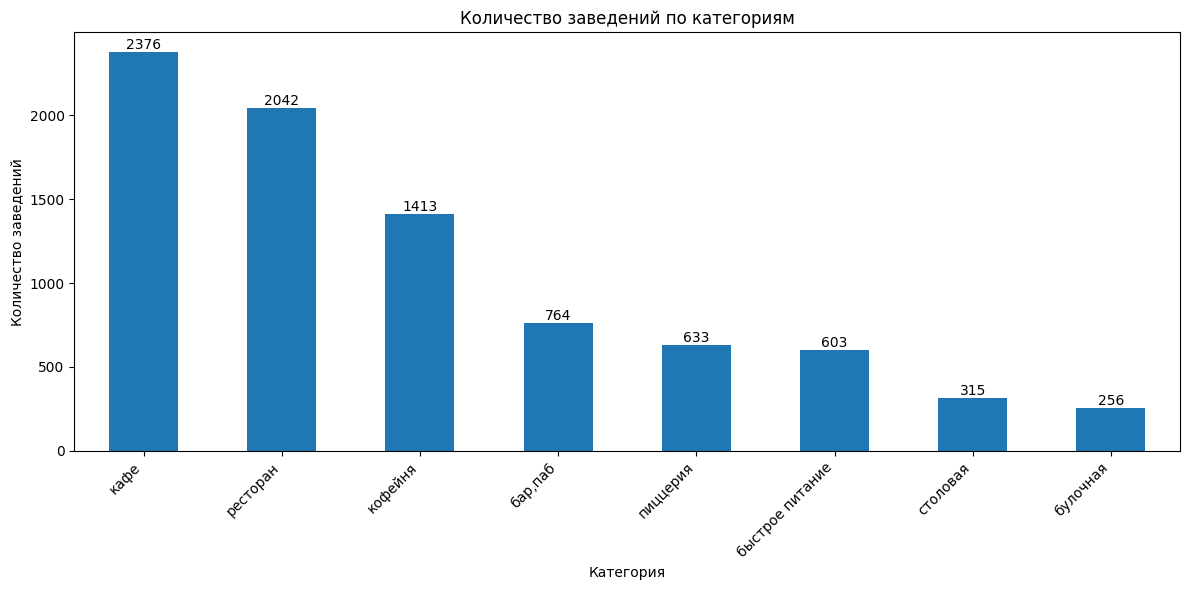

In [ ]:
#Выведем графически все категории заведений которые представлены в данных и количество заведений по каждой категории

# Получаем количество заведений по каждой категории
category_counts = data['category'].value_counts()

plt.figure(figsize=(12, 6))
# Строим столбчатую диаграмму
category_counts.plot(kind='bar')

# Добавляем текстовые метки с количеством заведений
for index, value in enumerate(category_counts):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.title('Количество заведений по категориям')
plt.xlabel('Категория')
plt.ylabel('Количество заведений')
plt.xticks(rotation=45, ha='right') # Поворачиваем метки по оси X для лучшей читаемости
plt.tight_layout() # Автоматически корректируем параметры области построения для плотного размещения
plt.show()



*   Самая плотная и популярная по количеству заведений общепита в Москве категория кафе (2378 шт), далее идут рестораны (2043 шт) и кофейни (1413 шт)
*   Баров и пабов в Москве в 2 раза меньше чем кофеен
* Пиццерий и заведений быстрого питания почти одинаковое количество (633 и 603 шт)
* Меньше всего в Москве столовых (315 шт) и булочных (256 шт)



---

### Задача 2

Какие административные районы Москвы присутствуют в данных? Исследуйте распределение количества заведений по административным районам Москвы, а также отдельно распределение заведений каждой категории в Центральном административном округе Москвы. Результат сопроводите подходящими визуализациями.

#### Построим тепловую карту распределений заведений в Москве по категориям

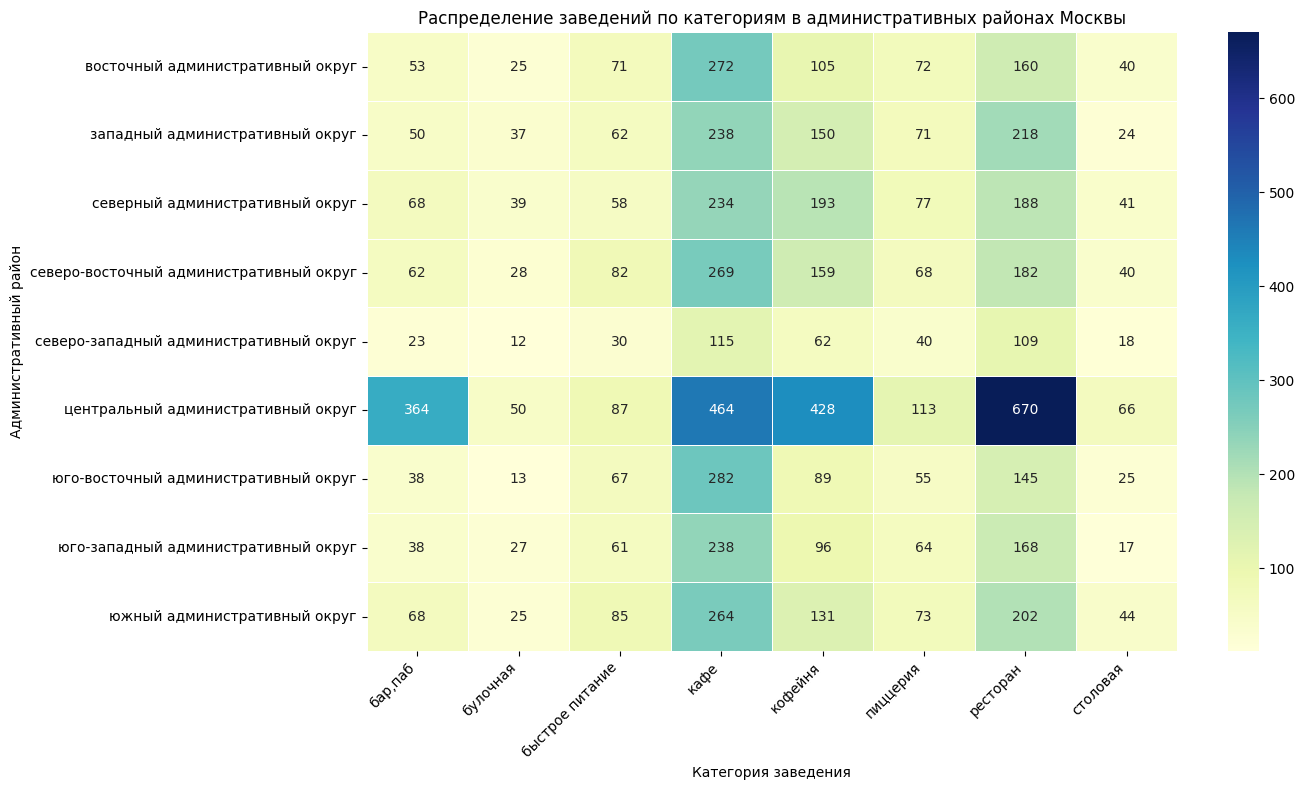

In [ ]:


# Подготовим данные для тепловой карты
# Сгруппируем по району и категории, затем посчитаем количество заведений
district_category_counts = data.groupby(['district', 'category']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(district_category_counts, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)

plt.title('Распределение заведений по категориям в административных районах Москвы')
plt.xlabel('Категория заведения')
plt.ylabel('Административный район')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Больше всего заведений находятся в ЦАО, из них 670 ресторанов, 464 кафе и 428 кофеен. Всего категория кафе чаще всего встречается в Москве, баров/пабов почти нет в не ЦАО районах. Категория быстрого питания чаще всего встречается в ЦАО и ЮАО, меньше всего быстрого питания в СЗАО. В целом СЗАО показывает наименьшую плотность количества заведений всех категорий в Москве.

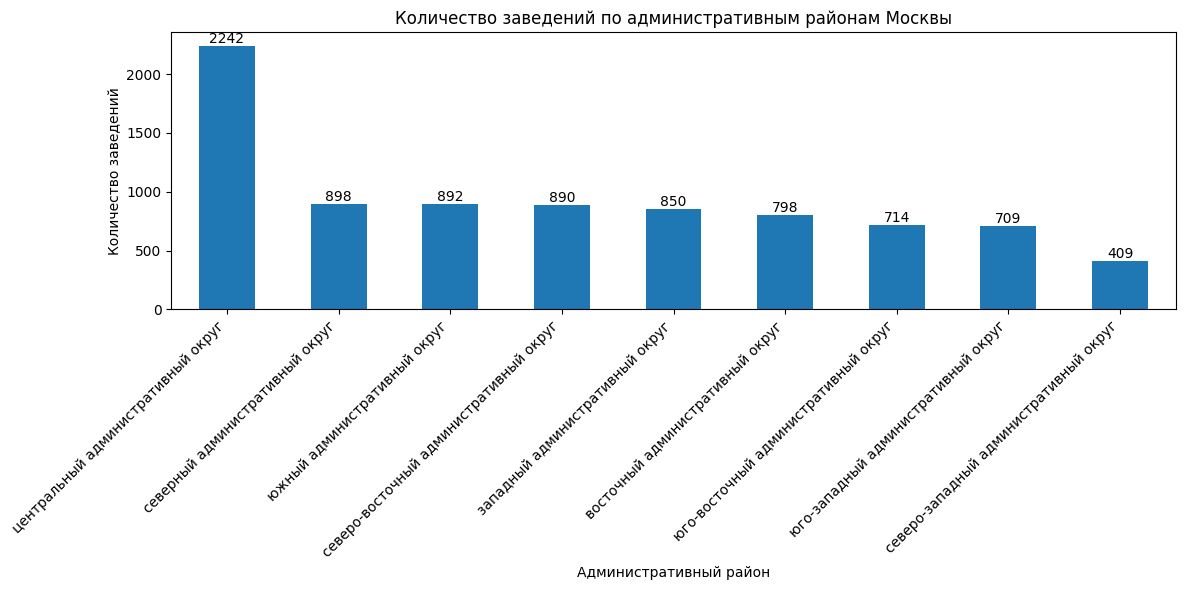

In [ ]:
# Получим количество заведений по каждому административному району
district_counts = data['district'].value_counts()

plt.figure(figsize=(12, 6))
# Строим столбчатую диаграмму
district_counts.plot(kind='bar')

# Добавляем текстовые метки с количеством заведений
for index, value in enumerate(district_counts):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.title('Количество заведений по административным районам Москвы')
plt.xlabel('Административный район')
plt.ylabel('Количество заведений')
plt.xticks(rotation=45, ha='right') # Поворачиваем метки по оси X для лучшей читаемости
plt.tight_layout() # Автоматически корректируем параметры области построения для плотного размещения
plt.show()

#### Распределение заведений в Центральном административном округе





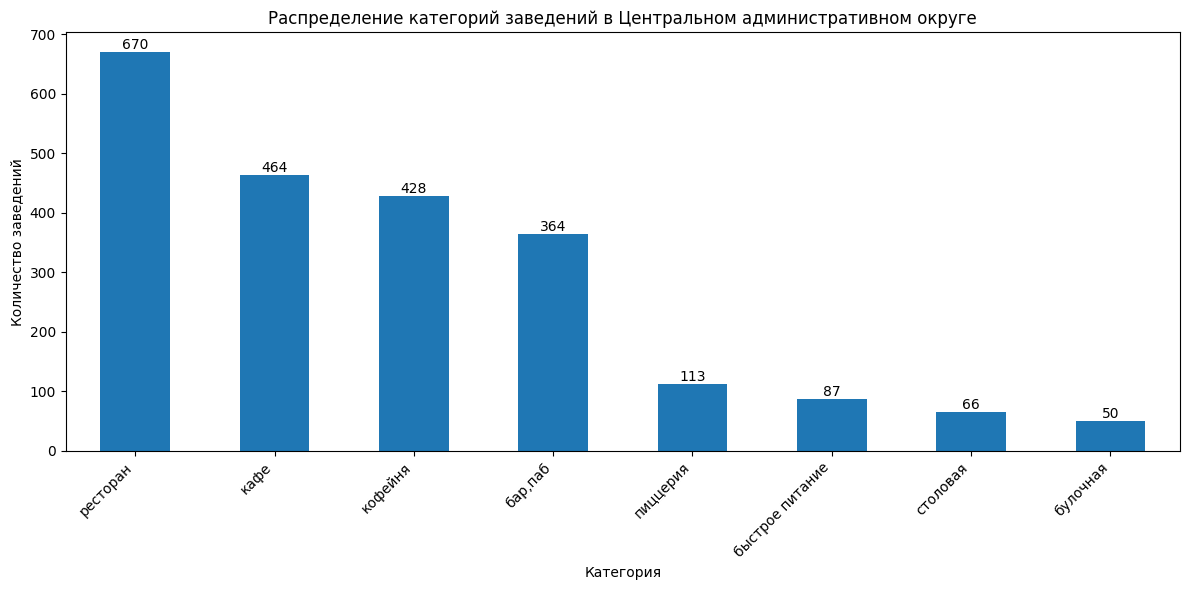

In [ ]:
# Фильтруем данные для Центрального административного округа
central_district_data = data[data['district'] == 'центральный административный округ']

# Получаем количество заведений по категориям в ЦАО
central_district_category_counts = central_district_data['category'].value_counts()

plt.figure(figsize=(12, 6))
# Строим столбчатую диаграмму
central_district_category_counts.plot(kind='bar')

# Добавляем текстовые метки с количеством заведений
for index, value in enumerate(central_district_category_counts):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.title('Распределение категорий заведений в Центральном административном округе')
plt.xlabel('Категория')
plt.ylabel('Количество заведений')
plt.xticks(rotation=45, ha='right') # Поворачиваем метки по оси X для лучшей читаемости
plt.tight_layout() # Автоматически корректируем параметры области построения для плотного размещения
plt.show()

---

### Задача 3

Изучите соотношение сетевых и несетевых заведений в целом по всем данным и в разрезе категорий заведения. Каких заведений больше — сетевых или несетевых? Какие категории заведений чаще являются сетевыми? Исследуйте данные, ответьте на вопросы и постройте необходимые визуализации.

Количество сетевых заведений в целом в процентах: 38.12
Количество несетевых заведений в целом в процентах: 61.88


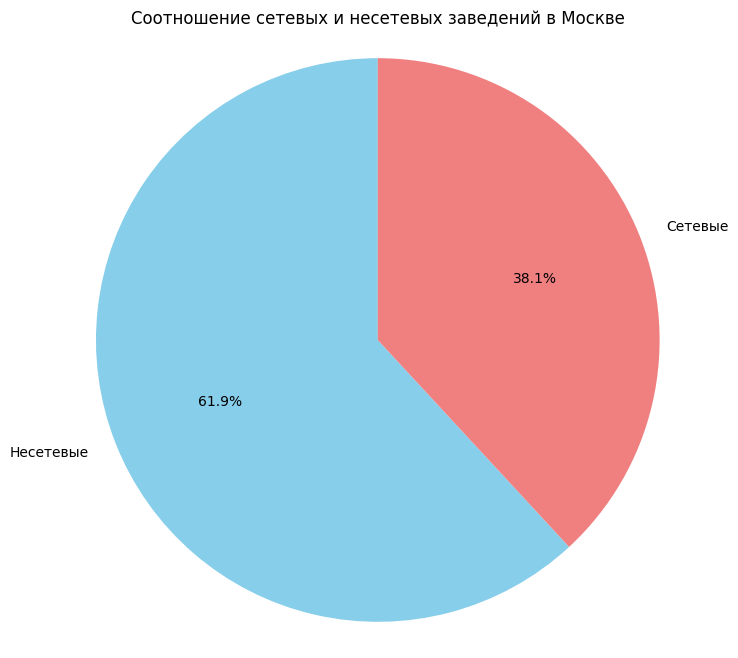

In [ ]:
#Выведем соотношение сетевых заведений в целом в процентах
print('Количество сетевых заведений в целом в процентах:', round(data['chain'].sum()/len(data)*100,2))
print('Количество несетевых заведений в целом в процентах:', round((len(data) - data['chain'].sum())/len(data)*100,2))

# Визуализация соотношения сетевых и несетевых заведений
chain_counts = data['chain'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(chain_counts, labels=['Несетевые', 'Сетевые'], autopct='%1.1f%%', startangle=90, colors=['skyblue', 'lightcoral'])
plt.title('Соотношение сетевых и несетевых заведений в Москве')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
# Выведем количество сетевых и несетевых заведений (chain=1) в разрезе категорий в абсолютном и относительном количестве
print('Количество сетевых заведений в разрезе категорий:')
chain_counts_by_category = data.groupby('category')['chain'].sum()
print(chain_counts_by_category.sort_values(ascending=False))

print('\nКоличество сетевых заведений в разрезе категорий в процентах:')
total_counts_by_category = data['category'].value_counts()
percentage_chain_by_category = round((chain_counts_by_category / total_counts_by_category) * 100,2)
print(percentage_chain_by_category.sort_values(ascending=False))

Количество сетевых заведений в разрезе категорий:
category
кафе               779
ресторан           729
кофейня            720
пиццерия           330
быстрое питание    232
бар,паб            168
булочная           157
столовая            88
Name: chain, dtype: int64

Количество сетевых заведений в разрезе категорий в процентах:
category
булочная           61.33
пиццерия           52.13
кофейня            50.96
быстрое питание    38.47
ресторан           35.70
кафе               32.79
столовая           27.94
бар,паб            21.99
dtype: float64


#### Распределение количества посадочных мест для сетевых и несетевых заведений по категориям

##### Выведем график совместного распределения количества сетевых и несетевых заведений в разрезе категорий


<Figure size 1400x700 with 0 Axes>

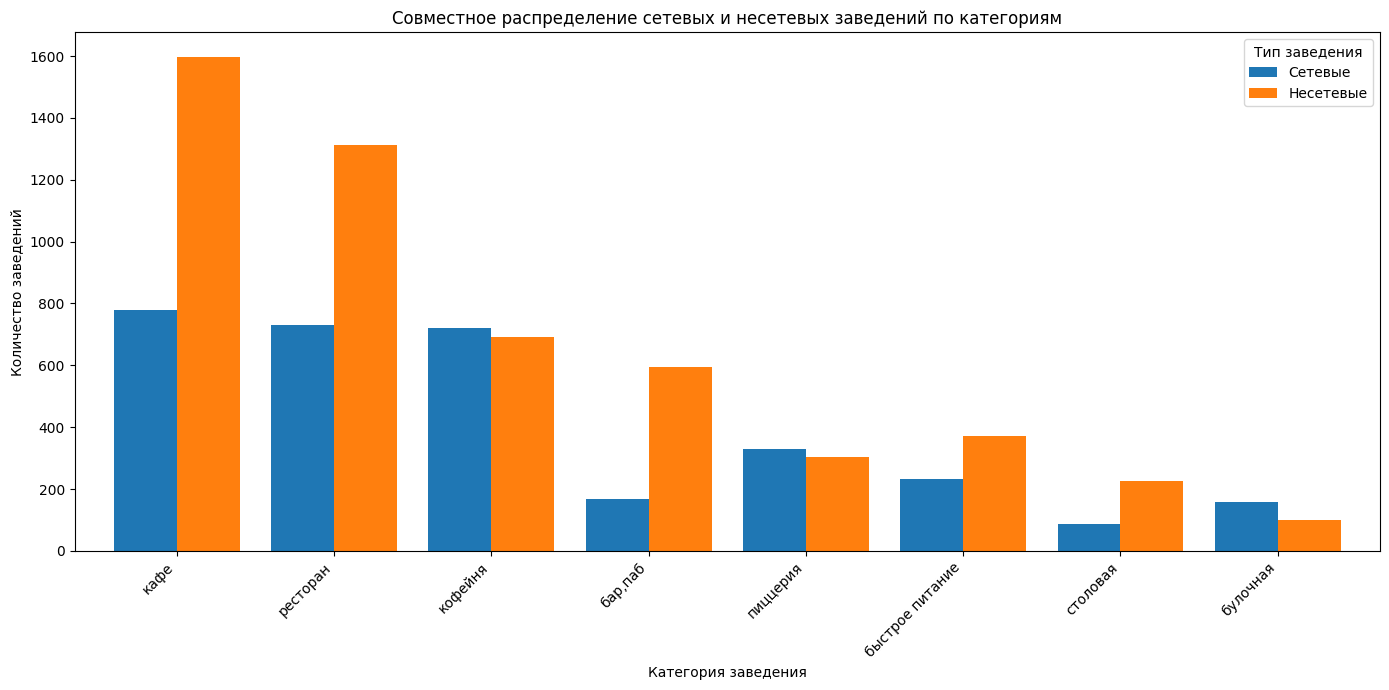

In [ ]:
# Объединим данные для построения графика
plot_data = pd.DataFrame({
    'Сетевые': chain_counts_by_category,
    'Несетевые': total_counts_by_category - chain_counts_by_category
})

# Сортируем по общему количеству заведений для лучшей читаемости
plot_data['Total'] = plot_data['Сетевые'] + plot_data['Несетевые']
plot_data = plot_data.sort_values(by='Total', ascending=False).drop(columns='Total')

plt.figure(figsize=(14, 7))
plot_data.plot(kind='bar', figsize=(14, 7), width=0.8)

plt.title('Совместное распределение сетевых и несетевых заведений по категориям')
plt.xlabel('Категория заведения')
plt.ylabel('Количество заведений')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Тип заведения')
plt.tight_layout()
plt.show()

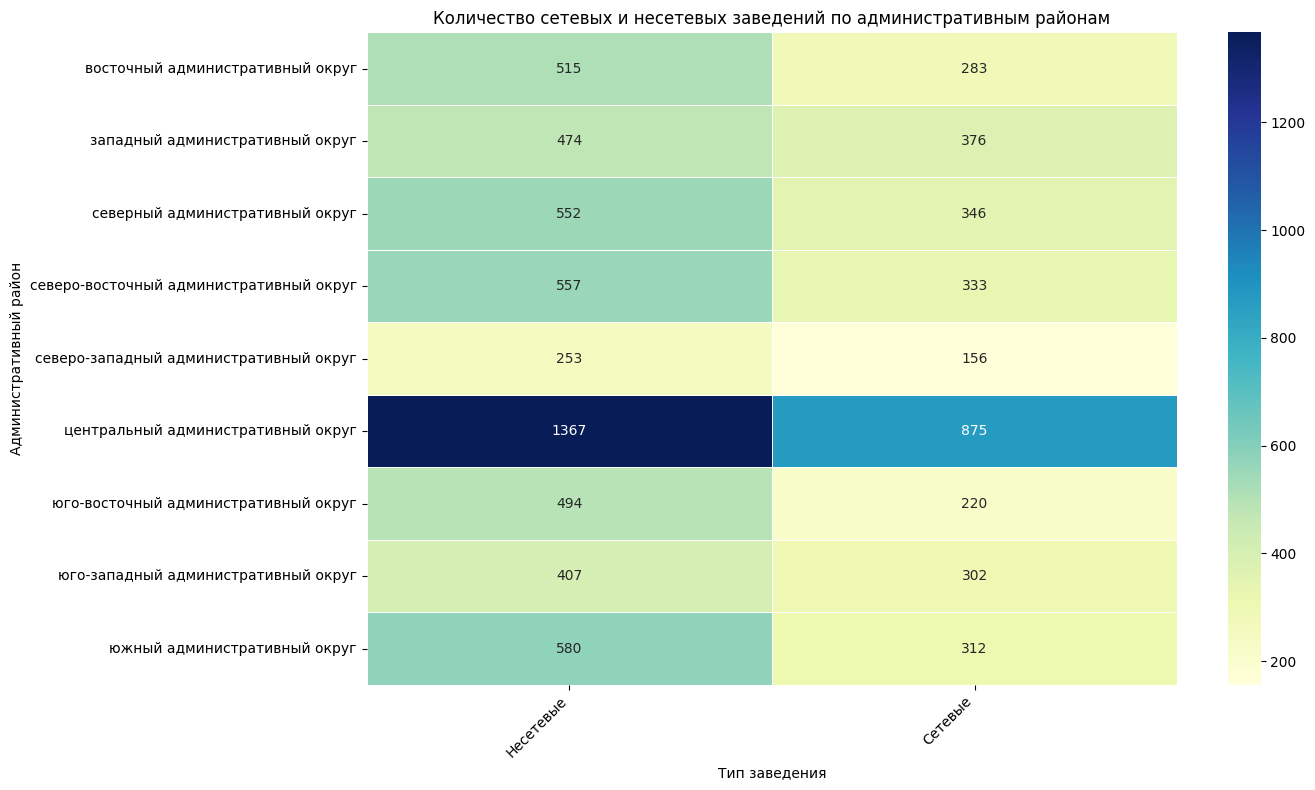

In [ ]:
chain_district_counts = data.groupby(['district', 'chain']).size().unstack(fill_value=0)
chain_district_counts.columns = ['Несетевые', 'Сетевые']

plt.figure(figsize=(14, 8))
sns.heatmap(chain_district_counts, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)

plt.title('Количество сетевых и несетевых заведений по административным районам')
plt.xlabel('Тип заведения')
plt.ylabel('Административный район')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


В целом в Москве больше несетевых заведений, чем сетевых (61.87% несетевых против 38.13% сетевых). Чаще более крупные заведения общественного питания оказываются сетевыми (кафе, рестораны, кофейни). Также в Москве больше сетевых пиццерий чем сетевых заведений быстрого питания. Больше всего сетевых заведений в ЦАО, а меньше всего в СЗАО. Возможно это связано с тем что бизнесам дорого приходится покупка франшизы, и они склоняются развиваться локально. Также возможно это связано с тем что численность сетей заведений меньше чем локальные места общепита.

---

### Задача 4

Исследуйте количество посадочных мест в заведениях. Встречаются ли в данных аномальные значения или выбросы? Если да, то с чем они могут быть связаны? Приведите для каждой категории заведений наиболее типичное для него количество посадочных мест. Результат сопроводите подходящими визуализациями.


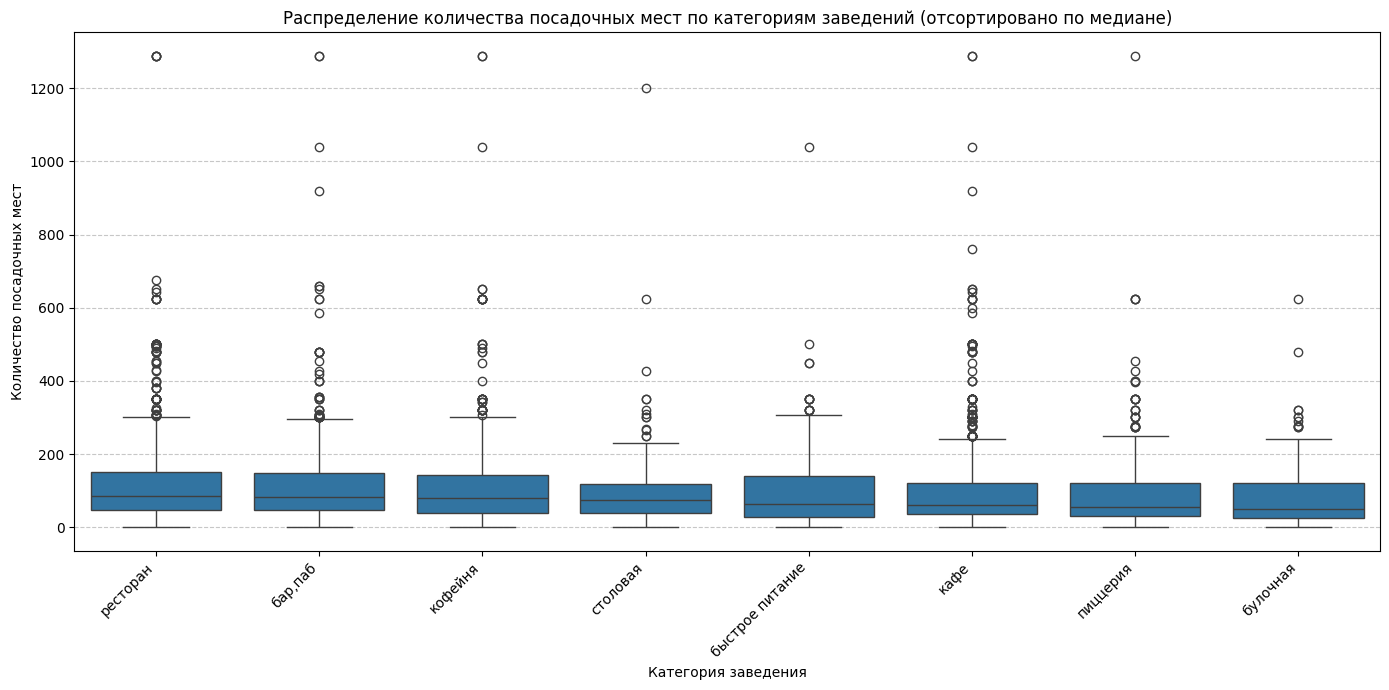

In [ ]:
# Построим boxplot график для исследования количества посадочных мест в заведениях

# Отсортируем категории по медианному количеству мест для лучшей читаемости
median_seats_order = data.groupby('category')['seats'].median().sort_values(ascending=False).index

plt.figure(figsize=(14, 7))
sns.boxplot(x='category', y='seats', data=data, order=median_seats_order)

plt.title('Распределение количества посадочных мест по категориям заведений (отсортировано по медиане)')
plt.xlabel('Категория заведения')
plt.ylabel('Количество посадочных мест')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

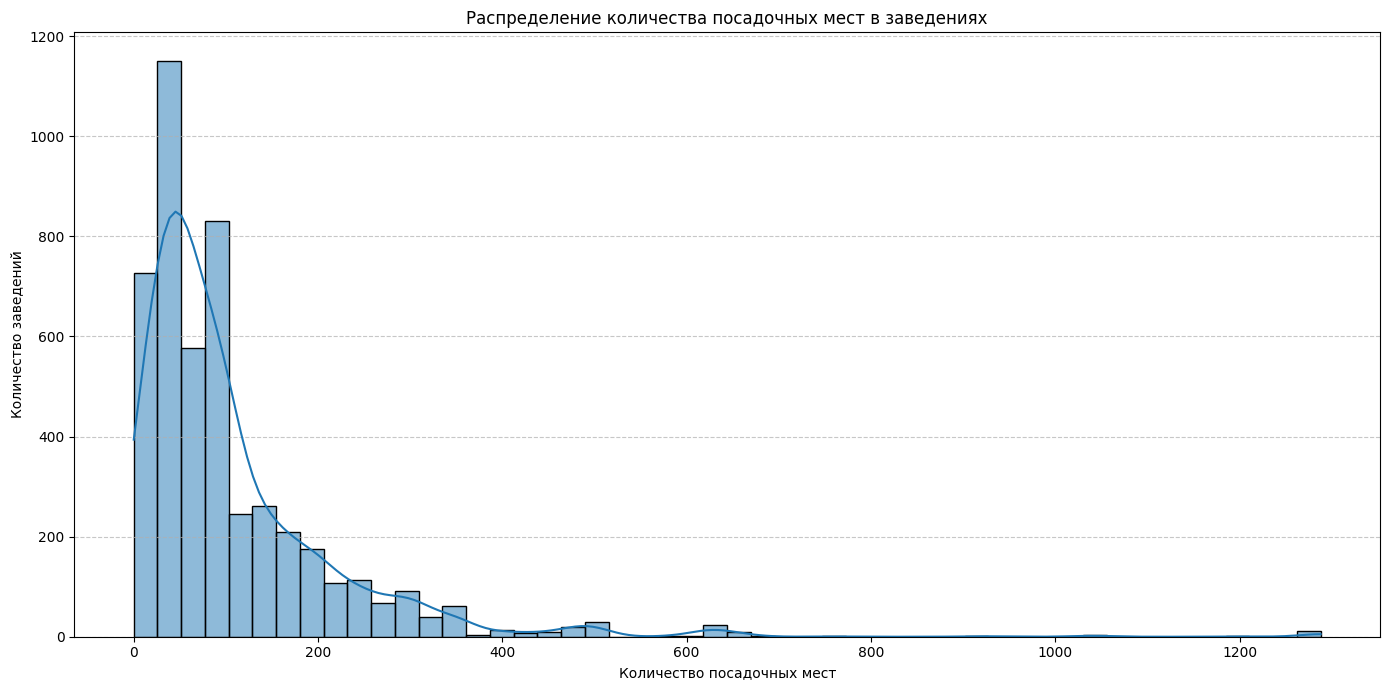

In [ ]:
# Построим гистограмму для исследования категорий заведений с аномально большим количества посадочных мест в заведениях
plt.figure(figsize=(14, 7))
sns.histplot(data=data['seats'].dropna().astype(float), kde=True, bins=50)

plt.title('Распределение количества посадочных мест в заведениях')
plt.xlabel('Количество посадочных мест')
plt.ylabel('Количество заведений')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
top_10_seats = data.sort_values(by='seats', ascending=False).head(10)
display(top_10_seats[['name', 'category', 'district', 'seats']])

,name,category,district,seats
6520,ян примус,ресторан,западный административный округ,1288
6570,мюнгер,пиццерия,западный административный округ,1288
6514,delonixcafe,ресторан,западный административный округ,1288
6680,пивной ресторан,"бар,паб",западный административный округ,1288
6686,японская кухня,ресторан,западный административный округ,1288
6637,one price coffee,кофейня,западный административный округ,1288
6654,гудбар,"бар,паб",западный административный округ,1288
6767,точка,кафе,западный административный округ,1288
6803,loft-cafe академия,кафе,западный административный округ,1288
6834,alternative coffee,кофейня,западный административный округ,1288


In [ ]:
data['seats'].describe()

,seats
count,4792.0
mean,108.361436
std,122.84113
min,0.0
25%,40.0
50%,75.0
75%,140.0
max,1288.0


75-й перцентиль количества посадочных мест: 140


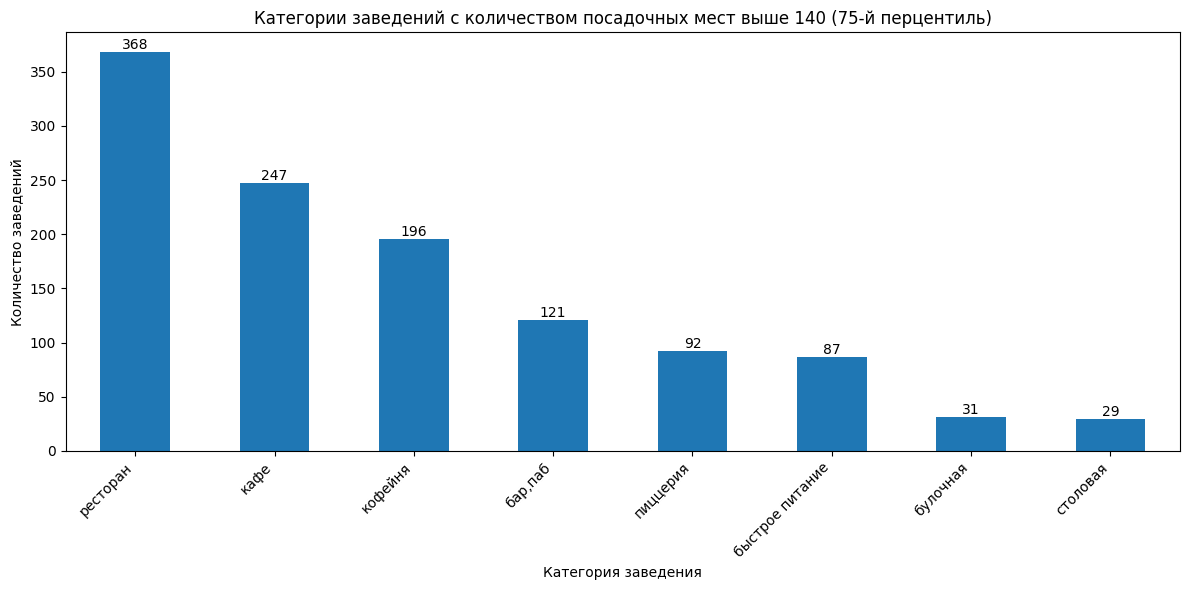

In [ ]:
#Исследуем какие категории заведей имеют аномальное количество посадочных мест
seats_75th_percentile = data['seats'].quantile(0.75)
print(f"75-й перцентиль количества посадочных мест: {seats_75th_percentile}")

anomalous_seats_data_75 = data[data['seats'] > seats_75th_percentile]

anomalous_category_counts_75 = anomalous_seats_data_75['category'].value_counts()

plt.figure(figsize=(12, 6))
anomalous_category_counts_75.plot(kind='bar')

for index, value in enumerate(anomalous_category_counts_75):
    plt.text(index, value, str(value), ha='center', va='bottom')

plt.title(f'Категории заведений с количеством посадочных мест выше {seats_75th_percentile} (75-й перцентиль)')
plt.xlabel('Категория заведения')
plt.ylabel('Количество заведений')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Типичное количество посадочных мест для каждой категории заведений

Медианное количество посадочных мест для каждой категории:


,seats
category,
ресторан,86.0
"бар,паб",82.0
кофейня,80.0
столовая,75.5
быстрое питание,65.0
кафе,60.0
пиццерия,55.0
булочная,50.0


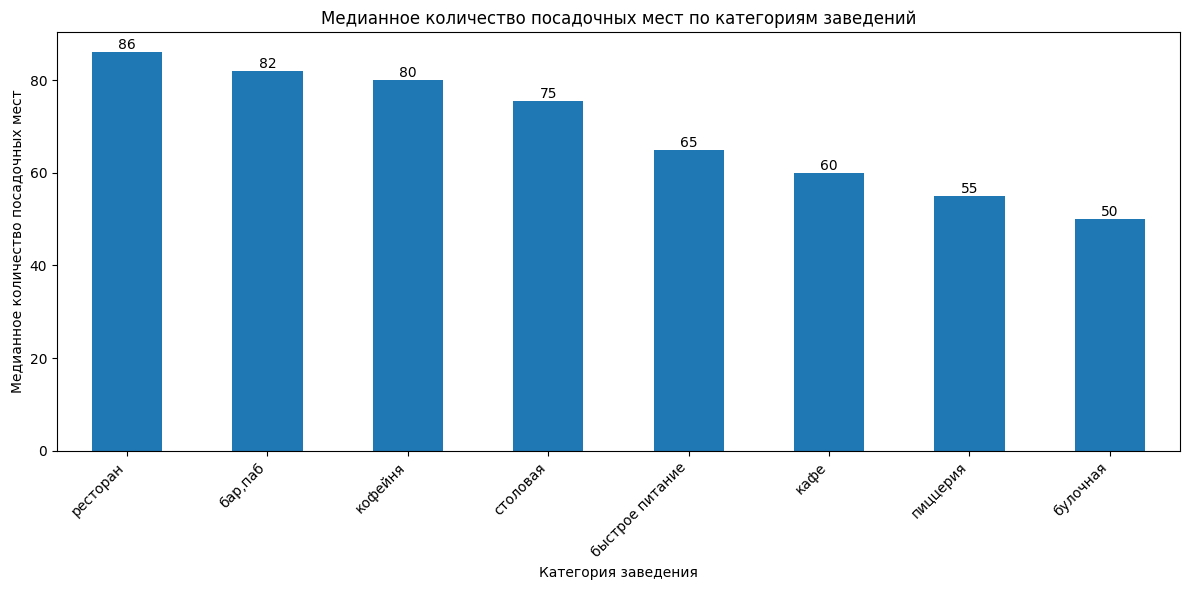

In [ ]:
typical_seats_by_category = data.groupby('category')['seats'].median().sort_values(ascending=False)

print("Медианное количество посадочных мест для каждой категории:")
display(typical_seats_by_category)

plt.figure(figsize=(12, 6))
typical_seats_by_category.plot(kind='bar')

for index, value in enumerate(typical_seats_by_category):
    plt.text(index, value, str(int(value)), ha='center', va='bottom')

plt.title('Медианное количество посадочных мест по категориям заведений')
plt.xlabel('Категория заведения')
plt.ylabel('Медианное количество посадочных мест')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Вывод по количеству посадочных мест:

*   **Распределение:** Гистограмма и boxplot подтверждают, что большинство заведений имеют небольшое количество посадочных мест. Распределение сильно скошено вправо, что указывает на наличие большого числа маленьких заведений и небольшого числа заведений с очень большим количеством мест.
*   **Аномальные значения:** Были выявлены заведения с аномально большим количеством мест (1288). Эти значения встречаются в основном в Западном административном округе и могут указывать на потенциальную аномалию в данных (возможно, ошибка ввода).
*   **Категории с аномально большим количеством мест (выше 75-го перцентиля - 140 мест):**
    *   **Рестораны** лидируют по количеству заведений с большим числом посадочных мест (369 шт).
    *   Далее следуют **кафе** (248 шт) и **кофейни** (196 шт).
    *   Булочные и столовые имеют наименьшее количество заведений с аномально большим числом мест.
*   **Типичное количество мест:**
    *   **Рестораны** и **Бары/пабы** имеют самое высокое медианное количество посадочных мест (по 80 мест).
    *   **Кафе** и **Пиццерии** имеют медиану в 60 мест.
    *   **Кофейни** и **Быстрое питание** имеют медиану в 30 мест.
    *   Наименьшее медианное количество мест у **булочных** (20 мест) и **столовых** (25 мест).

Этот анализ подтверждает, что рестораны и бары/пабы, как правило, являются более крупными заведениями, тогда как кофейни, фастфуд, столовые и булочные ориентированы на меньшую проходимость или потребление "на ходу".

---

### Задача 5

Исследуйте рейтинг заведений. Визуализируйте распределение средних рейтингов по категориям заведений. Сильно ли различаются усреднённые рейтинги для разных типов общепита?

In [ ]:
data['rating'].describe()

,rating
count,8402.000000
mean,4.230017
std,0.470320
min,1.000000
25%,4.100000
50%,4.300000
75%,4.400000
max,5.000000


In [ ]:
#Выведем средний рейтинг заведений по срезу категорий и покажем на графике


rating_by_category = data.groupby('category')['rating'].mean().sort_values(ascending=False)

print("Средний рейтинг заведений по категориям:")
display(rating_by_category)

Средний рейтинг заведений по категориям:


,rating
category,
"бар,паб",4.387696
пиццерия,4.301264
ресторан,4.290402
кофейня,4.277282
булочная,4.268359
столовая,4.211429
кафе,4.124285
быстрое питание,4.050249


### Топ-15 заведений с самым высоким рейтингом

In [ ]:
top_15_rated_establishments = data.sort_values(by='rating', ascending=False).head(15)
display(top_15_rated_establishments[['name', 'category', 'rating']])

,name,category,rating
7140,аммбар,ресторан,5.0
0,wowфли,кафе,5.0
609,напитки со всего мира,кофейня,5.0
6346,любовь пирогова,булочная,5.0
650,sushitop,кафе,5.0
3375,vegolife,"бар,паб",5.0
1395,zамания,пиццерия,5.0
1694,дача гашека,"бар,паб",5.0
1636,феникс кофе,кофейня,5.0
1621,i-cup,кофейня,5.0




Рейтинги по всем заведениям не сильно отличаются, в среднем все рейтинги не опускаются ниже оценки 4 для каждой категории. Несмотря на то что в среднем бары/пабы имеют самый высокий рейтинг в Москве, они не входят в топ-15 заведений с наивысшим рейтингом, куда входят преимущественно кафе и кофейни.

### Связь между районом и ценовой категорией заведений

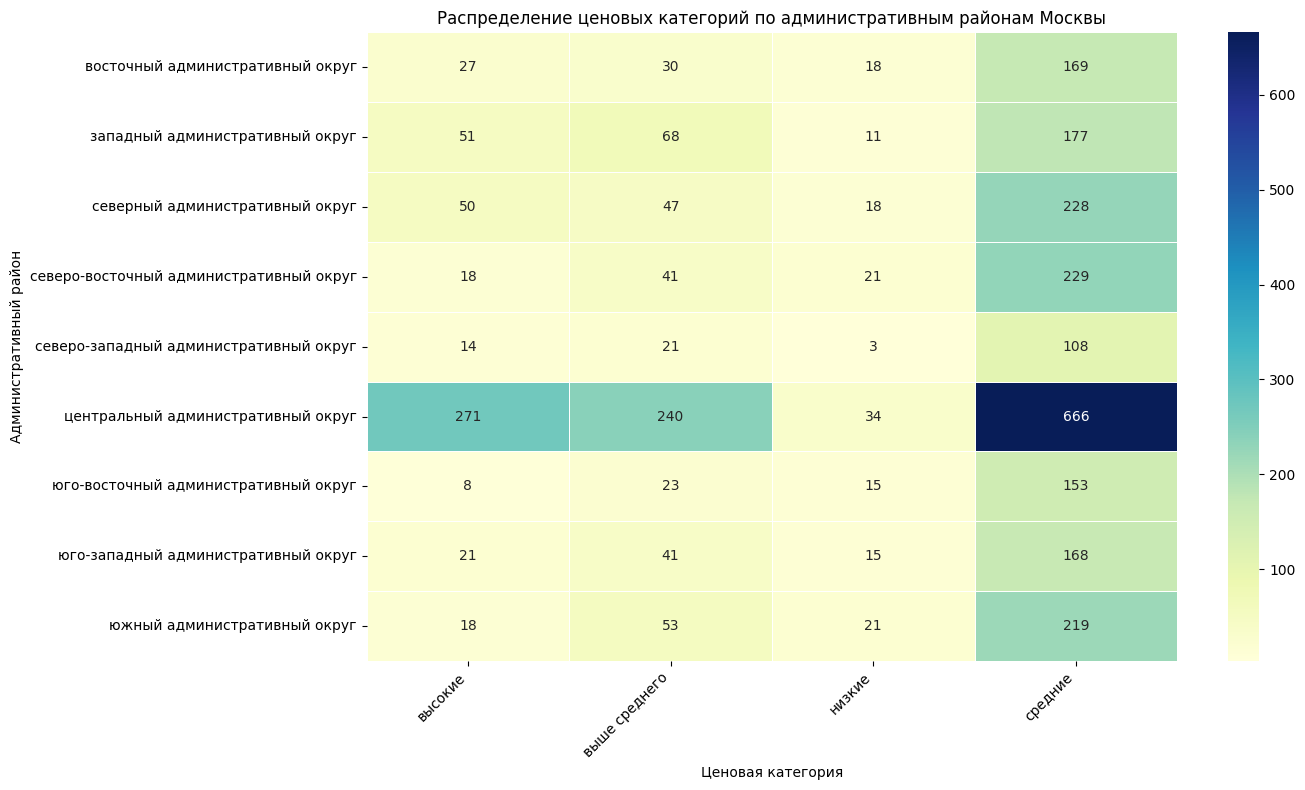

In [ ]:
# Удалим строки, где нет информации о ценовой категории для этого анализа
df_price_district = data.dropna(subset=['price', 'district']).copy()

# Создадим сводную таблицу для подсчета заведений по району и ценовой категории
price_district_pivot = df_price_district.groupby(['district', 'price']).size().unstack(fill_value=0)

# Для лучшей визуализации можно нормализовать данные по строкам (по районам)
# price_district_normalized = price_district_pivot.apply(lambda x: x / x.sum(), axis=1)

plt.figure(figsize=(14, 8))
sns.heatmap(price_district_pivot, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)

plt.title('Распределение ценовых категорий по административным районам Москвы')
plt.xlabel('Ценовая категория')
plt.ylabel('Административный район')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Из тепловой карты видно, что:

*   **Центральный административный округ (ЦАО)** лидирует по количеству заведений во всех ценовых категориях, особенно в категориях 'средние' и 'выше среднего'. Это ожидаемо, так как ЦАО является деловым и культурным центром, где сосредоточено большое количество разнообразных заведений.
*   **Низкие цены:** Заведения с 'низкими' ценами относительно равномерно распределены по районам, но их общее количество значительно меньше по сравнению с другими категориями.
*   **Выше среднего и высокие цены:** Эти категории чаще всего встречаются в ЦАО, а также в меньшей степени в Северном и Западном округах. Это может указывать на то, что более дорогие заведения предпочитают располагаться в центральных и более престижных районах.
*   **Средние цены:** Категория 'средние' цены является самой распространенной во всех административных округах, что говорит о широкой доступности заведений со средним чеком по всей Москве.

В целом, удаленность от центра (ЦАО) коррелирует с уменьшением количества заведений, особенно в более дорогих ценовых сегментах. Периферийные районы имеют меньше заведений, и доля заведений с 'высокими' и 'выше среднего' ценами там значительно ниже.

---

### Задача 6

Изучите, с какими данными показывают самую сильную корреляцию рейтинги заведений? Постройте и визуализируйте матрицу корреляции рейтинга заведения с разными данными: его категория, положение (административный район Москвы), статус сетевого заведения, количество мест, ценовая категория и признак, является ли заведения круглосуточным. Выберите самую сильную связь и проверьте её.

In [ ]:
import scipy.stats
import matplotlib.pyplot as plt
import seaborn as sns

# Make a copy of the dataframe to avoid modifying the original 'data'
corr_df = data.copy()

# 1. Convert 'is_24_7' from boolean to integer
corr_df['is_24_7'] = corr_df['is_24_7'].astype(int)

# 2. Encode 'price' (ordinal mapping)
# Define the order for price categories. NaNs will remain NaNs.
price_order = {'низкие': 0, 'средние': 1, 'выше среднего': 2, 'высокие': 3}
corr_df['price_encoded'] = corr_df['price'].map(price_order)

# 3. Encode 'category' and 'district' using pd.factorize
# This assigns an integer code to each unique category/district. No NaNs in original 'category' or 'district'.
corr_df['category_encoded'] = pd.factorize(corr_df['category'])[0]
corr_df['district_encoded'] = pd.factorize(corr_df['district'])[0]

# Select only the columns for correlation
correlation_features = [
    'rating',
    'chain',
    'seats',
    'is_24_7',
    'price_encoded',
    'category_encoded',
    'district_encoded',
    'middle_avg_bill',
    'middle_coffee_cup'
]
corr_data = corr_df[correlation_features]

# Create a dictionary to store p-values
p_values = {}

# Iterate through correlation features, excluding 'rating' itself
for feature in correlation_features:
    if feature == 'rating':
        continue

    # Drop NaNs for the specific pair of columns being tested
    temp_df = corr_data[['rating', feature]].dropna()

    if len(temp_df) > 1: # Ensure there's enough data to calculate correlation
        # Calculate Pearson correlation and p-value
        _, p_value = scipy.stats.pearsonr(temp_df['rating'], temp_df[feature])
        p_values[feature] = p_value
    else:
        p_values[feature] = float('nan') # Not enough data for calculation

p_values_df = pd.DataFrame.from_dict(p_values, orient='index', columns=['p_value'])
display(p_values_df.sort_values(by='p_value'))

,p_value
price_encoded,1.401429e-33
middle_avg_bill,3.526438e-25
is_24_7,2.009317e-21
category_encoded,3.771260e-05
district_encoded,7.656469e-03
middle_coffee_cup,2.013615e-02
seats,1.440107e-01
chain,1.625327e-01


Тк значения p-value меньше 0.01, мы можем с 99% Confidence level утверждать что нулевая гипотеза (H0: нет линейной зависимости) не принимается, то есть мы наблюдаем линейную зависимость каждой переменной с рейтингом

interval columns not set, guessing: ['rating', 'chain', 'seats', 'middle_avg_bill', 'middle_coffee_cup']


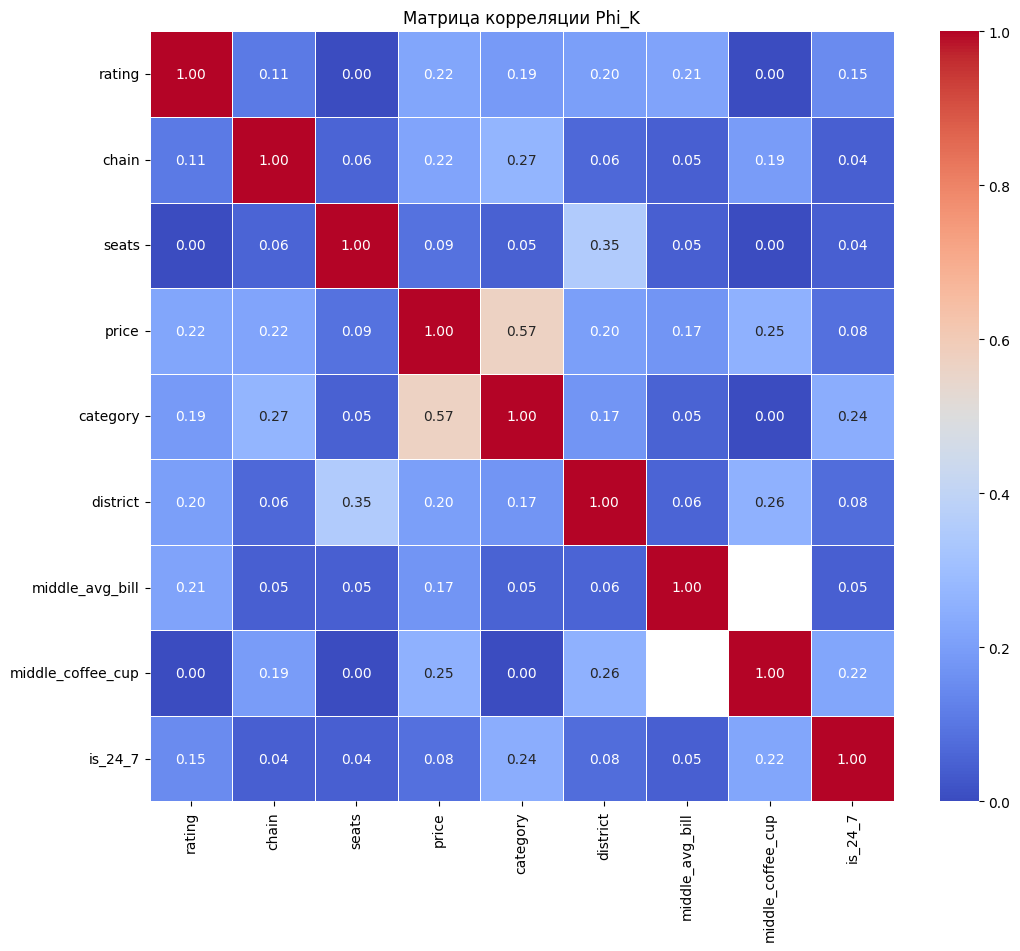


Средний рейтинг по ценовым категориям:


,rating
price,
высокие,4.436611
выше среднего,4.386348
средние,4.297874
низкие,4.173077


/tmp/ipykernel_9300/2437305788.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_rating_by_price.index, y=mean_rating_by_price.values, palette='viridis')


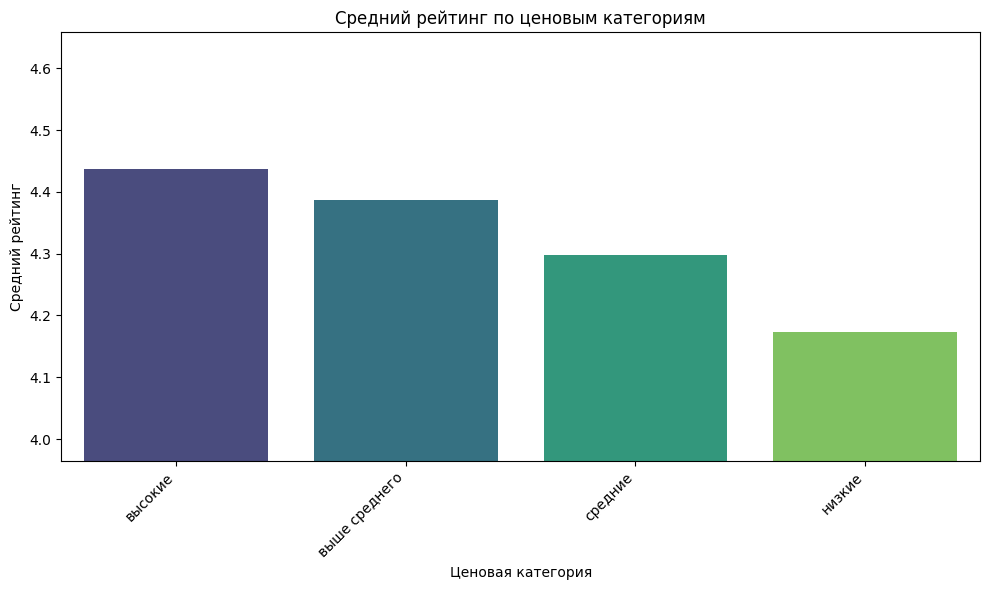

In [ ]:
#Посчитаем корреляцию

import phik
import phik.report
import matplotlib.pyplot as plt
import seaborn as sns

# # Make a copy of the dataframe to avoid modifying the original 'data'
# corr_df = data.copy()

# # 1. Convert 'is_24_7' from boolean to integer
# corr_df['is_24_7'] = corr_df['is_24_7'].astype(int)

# # 2. Encode 'price' (ordinal mapping)
# # Define the order for price categories. NaNs will remain NaNs.
# price_order = {'низкие': 0, 'средние': 1, 'выше среднего': 2, 'высокие': 3}
# corr_df['price_encoded'] = corr_df['price'].map(price_order)

# # 3. Encode 'category' and 'district' using pd.factorize
# # This assigns an integer code to each unique category/district. No NaNs in original 'category' or 'district'.
# corr_df['category_encoded'] = pd.factorize(corr_df['category'])[0]
# corr_df['district_encoded'] = pd.factorize(corr_df['district'])[0]

# # Select only the columns for correlation
# correlation_features = [
#     'rating',
#     'chain',
#     'seats',
#     'is_24_7',
#     'price_encoded',
#     'category_encoded',
#     'district_encoded',
#     'middle_avg_bill',
#     'middle_coffee_cup'
# ]
# corr_data = corr_df[correlation_features]

# # Pearson Correlation
# pearson_corr = corr_data.corr(method='pearson')

# # Visualization of Pearson Correlation
# plt.figure(figsize=(12, 10))
# sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
# plt.title('Матрица корреляции Пирсона')
# plt.show()

# Select relevant columns for Phi_K correlation, excluding high-cardinality text fields
phik_data = data[['rating', 'chain', 'seats', 'price', 'category', 'district', 'middle_avg_bill', 'middle_coffee_cup', 'is_24_7']].copy()

# Calculate the phik correlation matrix
phik_overview = phik_data.phik_matrix()

# Visualize the phik correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(phik_overview, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Матрица корреляции Phi_K')
plt.show()

# Based on the Phi_K matrix, 'price' has the strongest correlation with 'rating' (0.22).
# Let's check the average rating for each price category.

# Calculate mean rating by price category and sort for better visualization
mean_rating_by_price = data.groupby('price')['rating'].mean().sort_values(ascending=False)

print("\nСредний рейтинг по ценовым категориям:")
display(mean_rating_by_price)

# Visualize the mean rating by price category
plt.figure(figsize=(10, 6))
sns.barplot(x=mean_rating_by_price.index, y=mean_rating_by_price.values, palette='viridis')
plt.title('Средний рейтинг по ценовым категориям')
plt.xlabel('Ценовая категория')
plt.ylabel('Средний рейтинг')
plt.xticks(rotation=45, ha='right')
plt.ylim(min(mean_rating_by_price.values) * 0.95, max(mean_rating_by_price.values) * 1.05) # Adjust y-lim for better visual
plt.tight_layout()
plt.show()

* Связь рейтинга со всеми остальными факторами очень слабая но положительная. Максимальный коэффициент корреляции с рейтингом составляет 0.21 (с price_encoded), что указывает на очень слабую положительную линейную зависимость. Это означает, что заведения с более высокими ценовыми категориями могут иметь тенденцию к немного более высоким рейтингам, но эта связь незначительна

* Отсутствие сильных линейных зависимостей. Для большинства факторов, таких как chain (сетевое заведение), seats (количество мест), is_24_7 (круглосуточная работа), category_encoded (категория) и district_encoded (район), коэффициенты корреляции с рейтингом близки к нулю. Это говорит о том, что эти переменные не имеют сильной линейной связи с рейтингом

*  category_encoded и district_encoded —номинальные переменные, преобразованные в числа. Их корреляция отражает различия в рейтингах между группами, но не истинную числовую зависимость

* price имеет самую сильную корреляцию с 'rating' согласно матрице Phi_K что очевидно

 Рейтинг заведений в Москве, согласно данным, очень слабо коррелирует с большинством исследованных количественных факторов. Это может указывать на то, что на рейтинг влияют нелинейные факторы, не учтенные в данном анализе, или же на то, что качество обслуживания и продукта в различных типах заведений и ценовых категориях находится на достаточно высоком и стабильном уровне, что сглаживает выраженные различия в рейтингах.

---

### Задача 7

Сгруппируйте данные по названиям заведений и найдите топ-15 популярных сетей в Москве. Для них посчитайте значения среднего рейтинга. Под популярностью понимается количество заведений этой сети в регионе. К какой категории заведений они относятся? Результат сопроводите подходящими визуализациями.

In [ ]:
top_15_rated_establishments = data.sort_values(by='rating', ascending=False).head(15)
display(top_15_rated_establishments[['name', 'category', 'rating']])

,name,category,rating
7140,аммбар,ресторан,5.0
0,wowфли,кафе,5.0
609,напитки со всего мира,кофейня,5.0
6346,любовь пирогова,булочная,5.0
650,sushitop,кафе,5.0
3375,vegolife,"бар,паб",5.0
1395,zамания,пиццерия,5.0
1694,дача гашека,"бар,паб",5.0
1636,феникс кофе,кофейня,5.0
1621,i-cup,кофейня,5.0


#### Топ-15 популярных сетей и их характеристики

In [ ]:
# Фильтруем данные, чтобы оставить только сетевые заведения
chain_establishments = data[data['chain'] == 1]

# Группируем по названию заведения и считаем количество филиалов (популярность)
chain_popularity = chain_establishments['name'].value_counts()

# Выбираем топ-15 самых популярных сетей
top_15_chain_names = chain_popularity.head(15).index.tolist()

# Фильтруем исходный датафрейм, чтобы получить данные только для этих топ-15 сетей
top_15_chains_data = data[data['name'].isin(top_15_chain_names)]

# Для каждой из топ-15 сетей: считаем средний рейтинг и определяем самую частую категорию
top_chains_summary = top_15_chains_data.groupby('name').agg(
    count_establishments=('id', 'count'),
    average_rating=('rating', 'mean'),
    most_common_category=('category', lambda x: x.mode()[0]) # Определяем самую частую категорию
).sort_values(by='count_establishments', ascending=False)

display(top_chains_summary)

,count_establishments,average_rating,most_common_category
name,,,
шоколадница,120,4.177500,кофейня
домино'с пицца,77,4.171429,пиццерия
додо пицца,74,4.286486,пиццерия
one price coffee,72,4.069444,кофейня
яндекс лавка,69,3.872464,ресторан
cofix,65,4.075385,кофейня
prime,50,4.116000,ресторан
хинкальная,44,4.322727,кафе
кофепорт,42,4.147619,кофейня


##### Визуализация популярности топ-15 сетей

/tmp/ipykernel_9300/2842210859.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_chains_summary.index, y='count_establishments', data=top_chains_summary, palette='viridis')


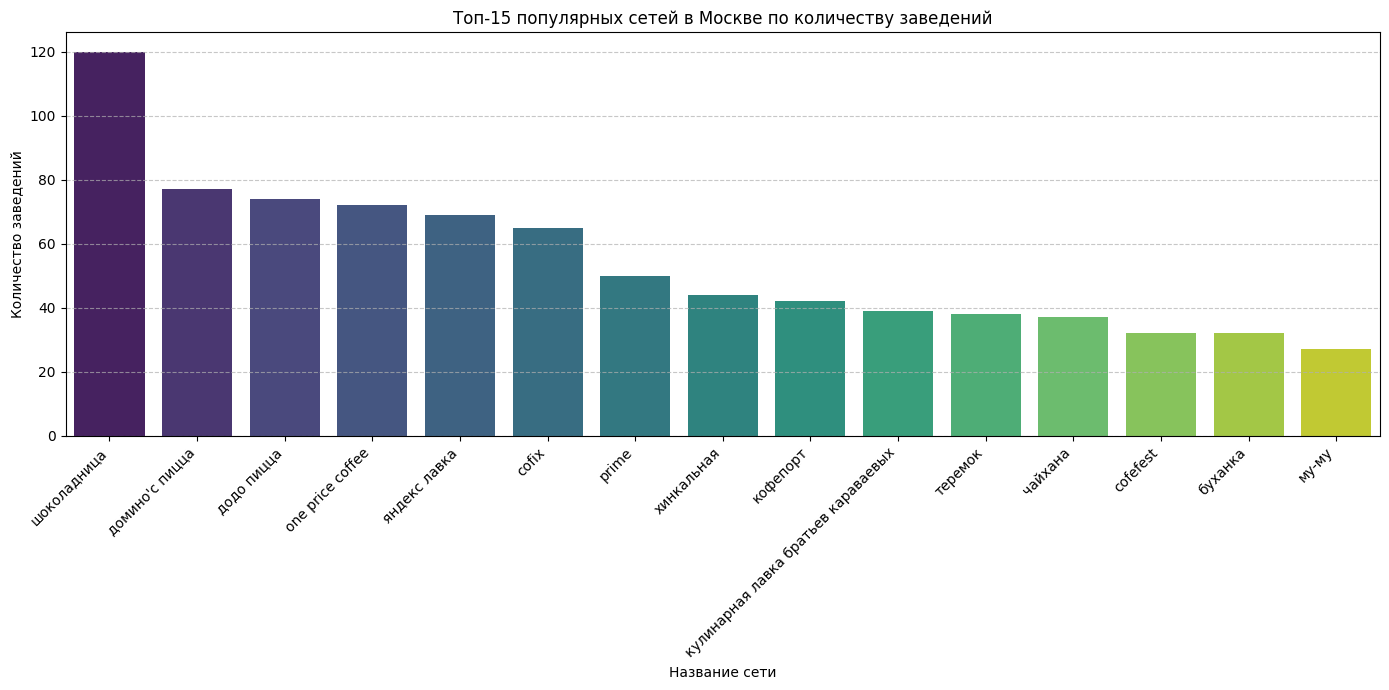

In [ ]:
plt.figure(figsize=(14, 7))
sns.barplot(x=top_chains_summary.index, y='count_establishments', data=top_chains_summary, palette='viridis')
plt.title('Топ-15 популярных сетей в Москве по количеству заведений')
plt.xlabel('Название сети')
plt.ylabel('Количество заведений')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### Визуализация среднего рейтинга топ-15 сетей

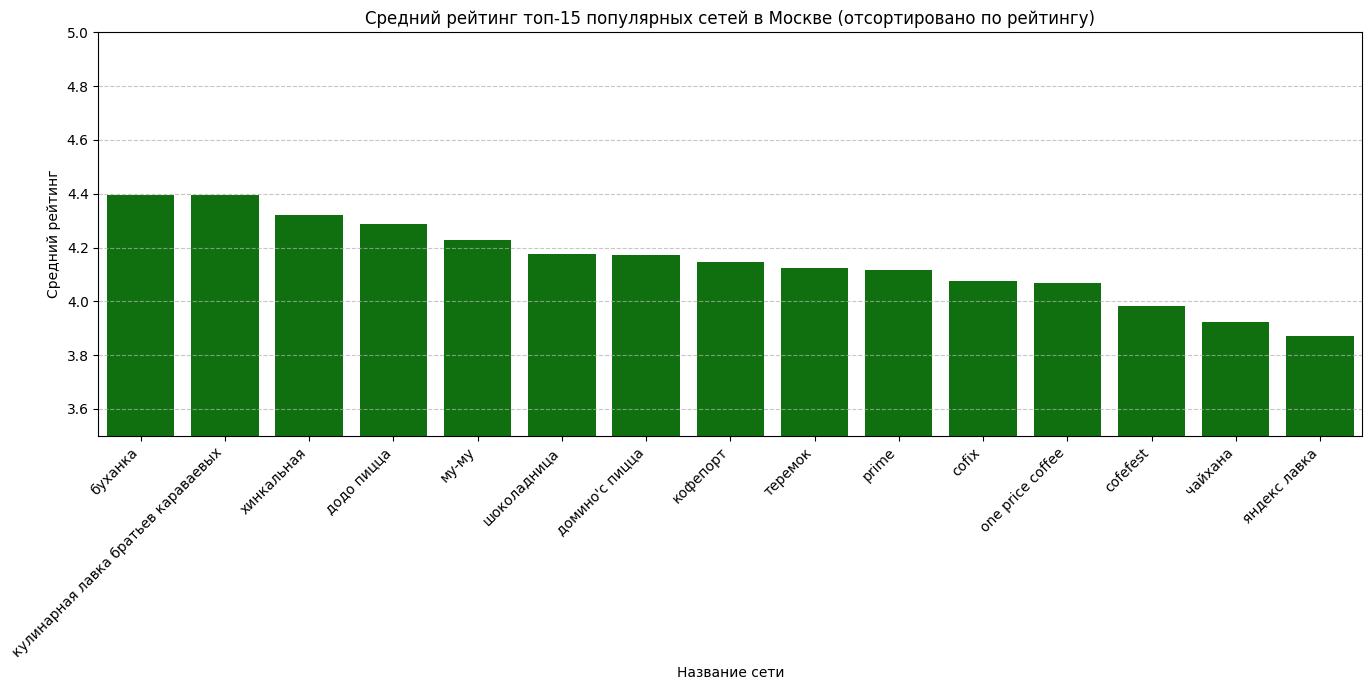

In [ ]:
plt.figure(figsize=(14, 7))
sns.barplot(x=top_chains_summary.sort_values(by='average_rating', ascending=False).index, y='average_rating', data=top_chains_summary.sort_values(by='average_rating', ascending=False), color='green')
plt.title('Средний рейтинг топ-15 популярных сетей в Москве (отсортировано по рейтингу)')
plt.xlabel('Название сети')
plt.ylabel('Средний рейтинг')
plt.xticks(rotation=45, ha='right')
plt.ylim(3.5, 5.0) # Ограничим ось Y для лучшей визуализации различий в рейтинге
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


* "Шоколадница" является самой крупной сетью среди проанализированных, значительно опережая другие по количеству филиалов
* Большинство популярных сетей представлены в категориях кофеен, пиццерий и ресторанов
Средние рейтинги у большинства топ-сетей достаточно высокие, что говорит о стабильном качестве. "Буханка" и "Кулинарная лавка братьев Караваевых" показали одни из самых высоких средних рейтингов среди топ-15
#### Таким образом, для открытия кафе в сетевом формате, стоит обратить внимание на популярные категории, такие как кофейни и пиццерии, и стремиться поддерживать высокий уровень качества, который отражается в рейтинге







---

### Задача 8

Изучите вариацию среднего чека заведения (столбец `middle_avg_bill`) в зависимости от района Москвы. Проанализируйте цены в Центральном административном округе и других. Как удалённость от центра влияет на цены в заведениях? Результат сопроводите подходящими визуализациями.


#### Анализ среднего чека по районам Москвы

Средний чек по административным районам Москвы:


,middle_avg_bill
district,
центральный административный округ,1191.057547
западный административный округ,1053.225490
северный административный округ,927.959627
южный административный округ,834.398089
северо-западный административный округ,822.222930
восточный административный округ,820.626923
юго-западный административный округ,792.561702
северо-восточный административный округ,716.611296
юго-восточный административный округ,654.097938


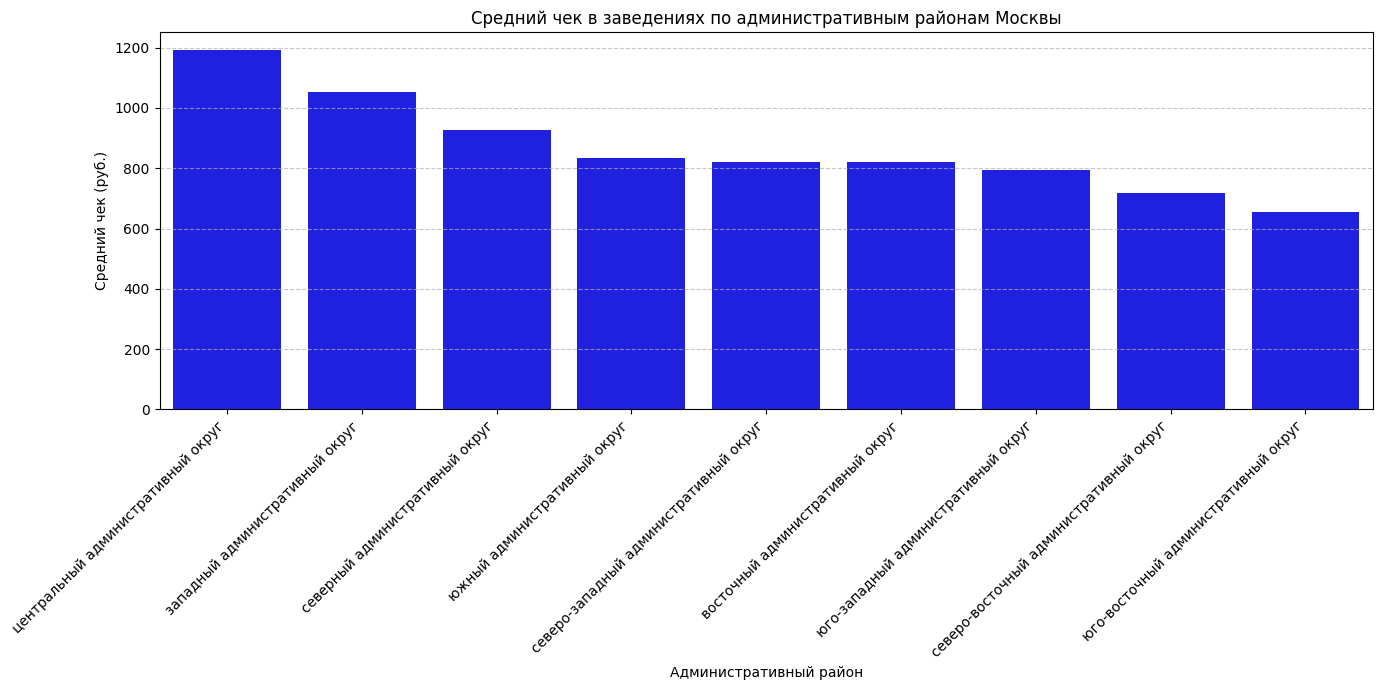

In [ ]:
# Группируем данные по району и рассчитываем средний чек
avg_bill_by_district = data.groupby('district')['middle_avg_bill'].mean().sort_values(ascending=False)

print("Средний чек по административным районам Москвы:")
display(avg_bill_by_district)

plt.figure(figsize=(14, 7))
sns.barplot(x=avg_bill_by_district.index, y=avg_bill_by_district.values, color='blue')
plt.title('Средний чек в заведениях по административным районам Москвы')
plt.xlabel('Административный район')
plt.ylabel('Средний чек (руб.)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##### Сравнение среднего чека в ЦАО с другими районами

/tmp/ipykernel_9300/1169437743.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Район', y='Средний чек (руб.)', data=comparison_data,


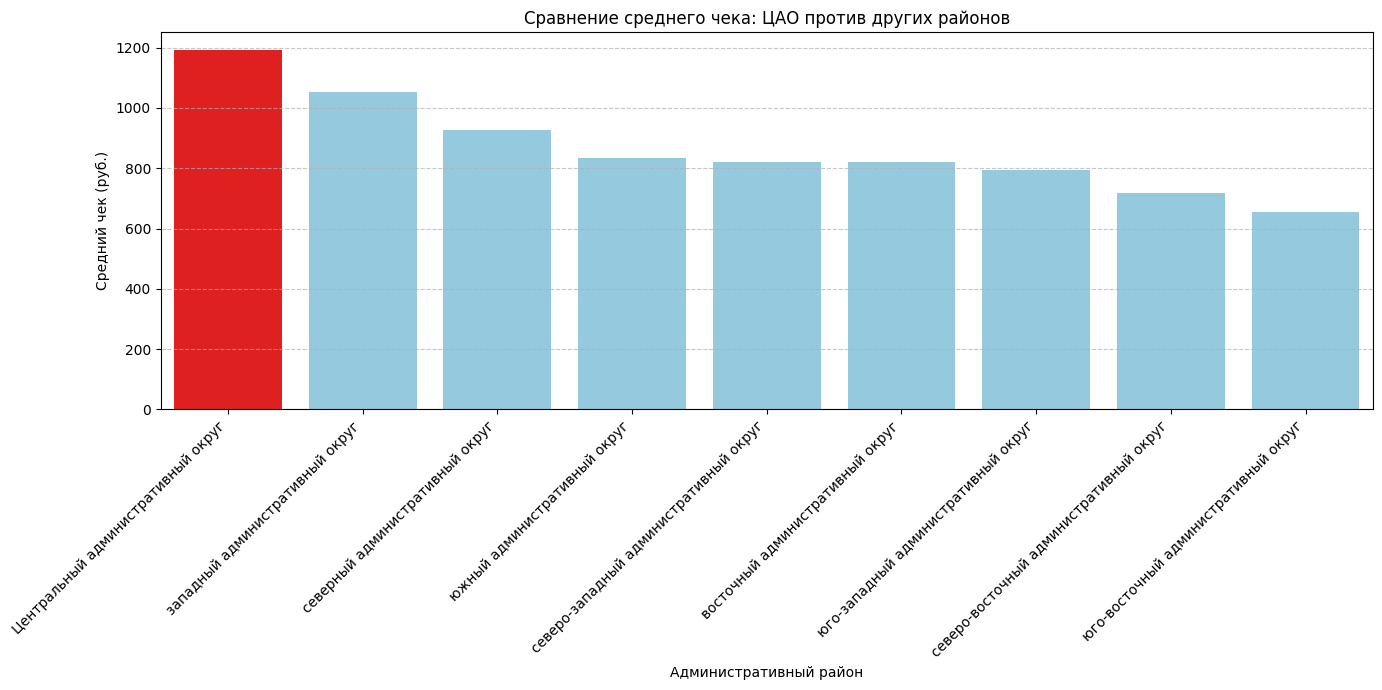

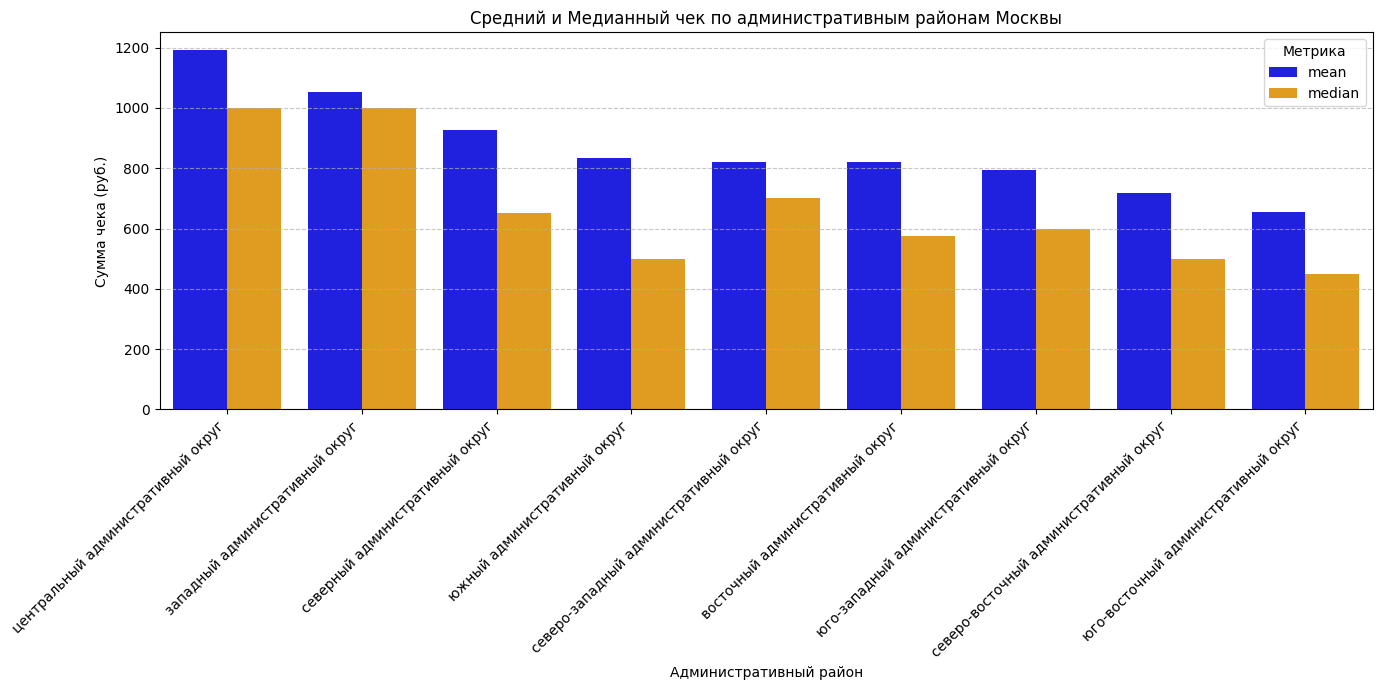

In [ ]:
# Выделим средний чек для ЦАО
cao_avg_bill = avg_bill_by_district.loc['центральный административный округ']

# Подготовим данные для сравнения
comparison_data = avg_bill_by_district.drop('центральный административный округ').reset_index()
comparison_data = comparison_data.rename(columns={'middle_avg_bill': 'Средний чек (руб.)', 'district': 'Район'})

# Добавим строку для ЦАО для наглядности
cao_row = pd.DataFrame([{'Район': 'Центральный административный округ', 'Средний чек (руб.)': cao_avg_bill}])
comparison_data = pd.concat([cao_row, comparison_data], ignore_index=True)

plt.figure(figsize=(14, 7))
sns.barplot(x='Район', y='Средний чек (руб.)', data=comparison_data,
            palette=['red' if x == 'Центральный административный округ' else 'skyblue' for x in comparison_data['Район']])
plt.title('Сравнение среднего чека: ЦАО против других районов')
plt.xlabel('Административный район')
plt.ylabel('Средний чек (руб.)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# Дополнительный барплот: средний и медианный чек по районам
# Группируем данные по району и рассчитываем средний и медианный чек
avg_median_bill_by_district = data.groupby('district')['middle_avg_bill'].agg(['mean', 'median']).sort_values(by='mean', ascending=False)

# Преобразуем для удобства визуализации
avg_median_bill_by_district_melted = avg_median_bill_by_district.reset_index().melt(id_vars='district', var_name='Метрика', value_name='Сумма чека')

plt.figure(figsize=(14, 7))
sns.barplot(x='district', y='Сумма чека', hue='Метрика', data=avg_median_bill_by_district_melted, palette={'mean': 'blue', 'median': 'orange'})
plt.title('Средний и Медианный чек по административным районам Москвы')
plt.xlabel('Административный район')
plt.ylabel('Сумма чека (руб.)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Метрика')
plt.tight_layout()
plt.show()


### Вывод по вариации среднего чека:

*   **Распределение среднего чека по районам:**
    *   Центральный административный округ (ЦАО) демонстрирует самый высокий средний чек среди всех районов Москвы, что подтверждает его статус делового и культурного центра.
    *   Западный административный округ занимает второе место по величине среднего чека, что также указывает на более высокую ценовую категорию заведений в этом районе.
    *   По мере удаления от центра Москвы средний чек в заведениях, как правило, снижается. Районы, расположенные на периферии, такие как Юго-Восточный административный округ, показывают самые низкие значения среднего чека

*   **Влияние удалённости от центра:**
    *   Наблюдается четкая тенденция: чем ближе район к центру (ЦАО), тем выше средний чек в заведениях. Это связано с более высокой стоимостью аренды, большей покупательной способностью населения и концентрацией премиум-заведений в центральных районах.
    *   Удалённость от центра приводит к снижению среднего чека, что может быть обусловлено меньшей платежеспособностью аудитории и стремлением заведений предлагать более доступные цены для привлечения клиентов

**Итог:** Расположение заведения в административном округе Москвы оказывает значительное влияние на уровень среднего чека. Заведения в центральных и престижных районах могут устанавливать более высокие цены, в то время как заведения в удаленных районах ориентированы на более низкий ценовой сегмент

---

### Промежуточный вывод

Обобщите полученные результаты, выделив, по вашему мнению, самые важные.



1.   Самая плотная и популярная по количеству заведений общепита в Москве категория кафе (2378 шт), далее идут рестораны (2043 шт) и кофейни (1413 шт)
Баров и пабов в Москве в 2 раза меньше чем кофеен
Пиццерий и заведений быстрого питания почти одинаковое количество (633 и 603 шт)
Меньше всего в Москве столовых (315 шт) и булочных (256 шт)
2.   Больше всего заведений находятся в ЦАО, из них 670 ресторанов, 464 кафе и 428 кофеен. Всего категория кафе чаще всего встречается в Москве, баров/пабов почти нет в не ЦАО районах. Категория быстрого питания чаще всего встречается в ЦАО и ЮАО, меньше всего быстрого питания в СЗАО. В целом СЗАО показывает наименьшую плотность количества заведений всех категорий в Москве
3. В целом в Москве больше несетевых заведений, чем сетевых (61.87% несетевых против 38.13% сетевых). Чаще более крупные заведения общественного питания оказываются сетевыми (кафе, рестораны, кофейни). Также в Москве больше сетевых пиццерий чем сетевых заведений быстрого питания. Больше всего сетевых заведений в ЦАО, а меньше всего в СЗАО. Возможно это связано с тем что бизнесам дорого приходится покупка франшизы, и они склоняются развиваться локально. Также возможно это связано с тем что численность сетей заведений меньше чем локальные места общепита
4. рестораны и бары/пабы, как правило, являются более крупными заведениями, тогда как кофейни, фастфуд, столовые и булочные ориентированы на меньшую проходимость или потребление "на ходу"
5. Рейтинги по всем заведениям не сильно отличаются, в среднем все рейтинги не опускаются ниже оценки 4 для каждой категории. Несмотря на то что в среднем бары/пабы имеют самый высокий рейтинг в Москве, они не входят в топ-15 заведений с наивысшим рейтингом, куда входят преимущественно кафе и кофейни. В целом, удаленность от центра (ЦАО) коррелирует с уменьшением количества заведений, особенно в более дорогих ценовых сегментах. Периферийные районы имеют меньше заведений, и доля заведений с 'высокими' и 'выше среднего' ценами там значительно ниже.
6. Рейтинг заведений в Москве, согласно данным, очень слабо коррелирует с большинством исследованных количественных факторов. Это может указывать на то, что на рейтинг влияют нелинейные факторы, не учтенные в данном анализе, или же на то, что качество обслуживания и продукта в различных типах заведений и ценовых категориях находится на достаточно высоком и стабильном уровне, что сглаживает выраженные различия в рейтингах
7. "Шоколадница" является самой крупной сетью среди проанализированных, значительно опережая другие по количеству филиалов
Большинство популярных сетей представлены в категориях кофеен, пиццерий и ресторанов Средние рейтинги у большинства топ-сетей достаточно высокие, что говорит о стабильном качестве. "Буханка" и "Кулинарная лавка братьев Караваевых" показали одни из самых высоких средних рейтингов среди топ-15
8. Расположение заведения в административном округе Москвы оказывает значительное влияние на уровень среднего чека. Заведения в центральных и престижных районах могут устанавливать более высокие цены, в то время как заведения в удаленных районах ориентированы на более низкий ценовой сегмент



---

### Итоговый вывод




1.   Самая плотная и популярная по количеству заведений общепита в Москве категория кафе (2378 шт), далее идут рестораны (2043 шт) и кофейни (1413 шт)
Баров и пабов в Москве в 2 раза меньше чем кофеен
Пиццерий и заведений быстрого питания почти одинаковое количество (633 и 603 шт)
Меньше всего в Москве столовых (315 шт) и булочных (256 шт)
2.   Больше всего заведений находятся в ЦАО, из них 670 ресторанов, 464 кафе и 428 кофеен. Всего категория кафе чаще всего встречается в Москве, баров/пабов почти нет в не ЦАО районах. Категория быстрого питания чаще всего встречается в ЦАО и ЮАО, меньше всего быстрого питания в СЗАО. В целом СЗАО показывает наименьшую плотность количества заведений всех категорий в Москве
3. В целом в Москве больше несетевых заведений, чем сетевых (61.87% несетевых против 38.13% сетевых). Чаще более крупные заведения общественного питания оказываются сетевыми (кафе, рестораны, кофейни). Также в Москве больше сетевых пиццерий чем сетевых заведений быстрого питания. Больше всего сетевых заведений в ЦАО, а меньше всего в СЗАО. Возможно это связано с тем что бизнесам дорого приходится покупка франшизы, и они склоняются развиваться локально. Также возможно это связано с тем что численность сетей заведений меньше чем локальные места общепита
4. рестораны и бары/пабы, как правило, являются более крупными заведениями, тогда как кофейни, фастфуд, столовые и булочные ориентированы на меньшую проходимость или потребление "на ходу"
5. Рейтинги по всем заведениям не сильно отличаются, в среднем все рейтинги не опускаются ниже оценки 4 для каждой категории. Несмотря на то что в среднем бары/пабы имеют самый высокий рейтинг в Москве, они не входят в топ-15 заведений с наивысшим рейтингом, куда входят преимущественно кафе и кофейни. В целом, удаленность от центра (ЦАО) коррелирует с уменьшением количества заведений, особенно в более дорогих ценовых сегментах. Периферийные районы имеют меньше заведений, и доля заведений с 'высокими' и 'выше среднего' ценами там значительно ниже.
6. Рейтинг заведений в Москве, согласно данным, очень слабо коррелирует с большинством исследованных количественных факторов. Это может указывать на то, что на рейтинг влияют нелинейные факторы, не учтенные в данном анализе, или же на то, что качество обслуживания и продукта в различных типах заведений и ценовых категориях находится на достаточно высоком и стабильном уровне, что сглаживает выраженные различия в рейтингах
7. "Шоколадница" является самой крупной сетью среди проанализированных, значительно опережая другие по количеству филиалов
Большинство популярных сетей представлены в категориях кофеен, пиццерий и ресторанов Средние рейтинги у большинства топ-сетей достаточно высокие, что говорит о стабильном качестве. "Буханка" и "Кулинарная лавка братьев Караваевых" показали одни из самых высоких средних рейтингов среди топ-15
8. Расположение заведения в административном округе Москвы оказывает значительное влияние на уровень среднего чека. Заведения в центральных и престижных районах могут устанавливать более высокие цены, в то время как заведения в удаленных районах ориентированы на более низкий ценовой сегмент



## Итоговый вывод по проекту

### 1. Цель проекта
Целью проекта было проведение исследовательского анализа рынка общественного питания в Москве, чтобы на основе полученных данных выбрать оптимальное расположение нового кафе, определить ценовую политику и сформировать меню.

### 2. Общая характеристика данных
Изначально были предоставлены два датасета: `rest_info.csv` (8406 строк, 9 столбцов) и `rest_price.csv` (4058 строк, 5 столбцов). После объединения по ключу `id`, итоговый датасет `data` содержит 8406 строк и 13 столбцов.

*   **Соответствие описанию:** Данные в целом соответствовали заявленному описанию столбцов.
*   **Пропуски:** Обнаружено значительное количество пропусков в столбцах: `hours` (6.38%), `seats` (42.96%), `price` (60.56%), `avg_bill` (54.60%), `middle_avg_bill` (62.54%), `middle_coffee_cup` (93.64%). Анализ показал, что пропуски носят характер MNAR (Missing Not At Random) или MAR (Missing At Random), и их удаление или заполнение медианой/модой могло бы исказить результаты анализа, поэтому было принято решение оставить пропуски как есть для сохранения полноты информации.
*   **Дубликаты:** Явных дубликатов в объединенном датасете не обнаружено (0 строк).
*   **Типы данных:** Столбец `seats` изначально имел тип `float64`, что было некорректно для количества посадочных мест. Другие категориальные столбцы имели тип `object`.

### 3. Детализация проведенных работ
*   **Преобразование типов данных:** Столбец `seats` был успешно преобразован в `Int64` (nullable integer), что позволило корректно хранить целочисленные значения и `NaN`.
*   **Нормализация текстовых данных:** Столбцы `name`, `address`, `district`, `avg_bill` были приведены к нижнему регистру для облегчения поиска неявных дубликатов и стандартизации.
*   **Обработка пропусков:** Пропуски в данных не были удалены и не были заполнены, так как их природа (MAR/MNAR) и высокий процент в некоторых столбцах могли привести к искажению анализа. Например, отсутствие информации о часах работы не всегда означало отсутствие часов, а скорее отсутствие записи. Отсутствие данных о посадочных местах или ценах могло быть связано с форматом заведения или отсутствием открытых данных.
*   **Обработка дубликатов:** Проведена проверка на явные дубликаты (`data.duplicated().sum()`), дубликатов не обнаружено.
*   **Создание нового признака:** Добавлен новый логический столбец `is_24_7`, указывающий, работает ли заведение круглосуточно (True/False).

### 4. Описание нового срезанного датасета
Для проведения анализа не создавался принципиально новый срезанный датасет. Вместо этого, оригинальный объединенный датасет `data` был модифицирован (изменение типов, нормализация) и использовался для различных срезов и агрегаций в процессе исследовательского анализа. Например, для анализа среднего чека по районам использовался `df_price_district` (отфильтрованный от `NaN` в `price` и `district`), для анализа популярных сетей — `chain_establishments` (отфильтрованный по `chain=1`). Общий размер данных остался 8406 строк.

### 5. Категоризация данных (Ключевые выводы исследовательского анализа)

*   **Категории заведений:** Наиболее популярные категории заведений в Москве — кафе (2378), рестораны (2043) и кофейни (1413). Наименее представлены столовые (315) и булочные (256).
*   **Распределение по районам:** Центральный административный округ (ЦАО) лидирует по количеству заведений (2242), с наибольшей концентрацией ресторанов (670), кафе (464) и кофеен (428). Северо-Западный административный округ имеет наименьшую плотность заведений.
*   **Сетевые vs. Несетевые:** В Москве преобладают несетевые заведения (61.87% против 38.13% сетевых). Наиболее часто сетевыми являются булочные (61.33%), пиццерии (52.13%) и кофейни (50.96%). ЦАО имеет наибольшее количество как сетевых, так и несетевых заведений.
*   **Количество посадочных мест:** Большинство заведений имеют небольшое количество посадочных мест. Медианное количество мест: рестораны и бары/пабы (80-86), кафе и пиццерии (55-60), кофейни и быстрое питание (30), булочные и столовые (20-25). Заведения с аномально большим количеством мест (более 140) чаще всего встречаются среди ресторанов (369 шт), кафе (248 шт) и кофеен (196 шт).
*   **Рейтинг заведений:** Средние рейтинги по всем категориям не сильно отличаются (в среднем выше 4.0). Бары/пабы имеют самый высокий средний рейтинг. Корреляция рейтинга с большинством исследованных факторов (категория, район, сетевой статус, количество мест, цена, круглосуточная работа) очень слабая, что указывает на сложность предсказания рейтинга только на основе этих параметров.
*   **Популярные сети:** Среди топ-15 популярных сетей, Шоколадница является самой крупной. Большинство популярных сетей представлены в категориях кофеен, пиццерий и ресторанов. Средние рейтинги у них достаточно высокие, что свидетельствует о стабильном качестве.


*   **Средний чек:** ЦАО демонстрирует самый высокий средний чек. С увеличением удаленности от центра Москвы средний чек снижается. Это связано с высокой стоимостью аренды и покупательной способностью в центре.

### 6. Заключительное резюме
На основе проведенного анализа можно сделать следующие выводы и рекомендации для открытия нового кафе:

*   **Расположение:** Центральный административный округ (ЦАО) является наиболее привлекательным районом с точки зрения плотности заведений и самого высокого среднего чека. Однако, это также означает высокую конкуренцию. Западный административный округ также показывает высокий средний чек и может быть рассмотрен. Если цель — более доступное ценовое предложение, стоит рассмотреть районы, удаленные от центра.
*   **Ценовая категория и меню:** Заведения со средним чеком наиболее распространены по всей Москве, что указывает на широкий спрос. Для ЦАО можно рассмотреть более высокие ценовые категории. Категории кафе, ресторанов и кофеен являются наиболее популярными. Если планируется открытие сетевого заведения, стоит обратить внимание на категории булочных, пиццерий и кофеен, которые чаще представлены в сетевом формате.
*   **Формат заведения:** Если планируется заведение с большим количеством посадочных мест, рестораны и бары/пабы показывают наибольшую медианную вместимость. Если же формат предполагает небольшую проходимость или концепцию на ходу, то кофейни, фастфуд или булочные будут более подходящими.


*   **Рейтинг:** Высокие рейтинги характерны для большинства заведений, что подчеркивает важность поддержания высокого качества обслуживания и продукта, так как именно эти факторы, вероятно, влияют на рейтинг сильнее, чем географическое положение или категория заведения.